# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split


In [196]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/harleenkaur/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [197]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/harleenkaur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [198]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/harleenkaur/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [199]:
plt.style.use('ggplot')
sns.set(style='whitegrid')

In [200]:
train_df = pd.read_csv("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/train.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/test.csv")

In [201]:
train_df.shape

(10003, 2)

In [202]:
test_df.shape

(3080, 2)

In [203]:
train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [204]:
import requests
categories_response = requests.get("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/categories.json")
categories = categories_response.json()

In [205]:
len(categories)

77

In [206]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10003 non-null  object
 1   category  10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [207]:
train_df.isnull().sum()

text        0
category    0
dtype: int64

In [208]:
test_df.isnull().sum()

text        0
category    0
dtype: int64

In [209]:
def preprocess_text(text):
  text = text.lower()
  text = re.sub(r'[^\w\s\d]', '', text)#removed punctuations
  return text

In [210]:
def tokenize_text(text):
  stop_words = set(stopwords.words('english'))
  lemmatizer = WordNetLemmatizer()
  tokens = word_tokenize(text)
  tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
  lemmatized = [lemmatizer.lemmatize(token) for token in tokens]

  return lemmatized

In [211]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/harleenkaur/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [212]:
train_df['preprocessed_text'] = train_df['text'].apply(preprocess_text)
train_df['tokLem_text'] = train_df['preprocessed_text'].apply(tokenize_text)
train_df['processed_txt'] = train_df['tokLem_text'].apply(lambda x: ' '.join(x))
test_df['preprocessed_text'] = test_df['text'].apply(preprocess_text)
test_df['tokLem_text'] = test_df['preprocessed_text'].apply(tokenize_text)
test_df['processed_txt'] = test_df['tokLem_text'].apply(lambda x: ' '.join(x))

In [213]:
train_df.head()

,text,category,preprocessed_text,tokLem_text,processed_txt
0,I am still waiting on my card?,card_arrival,i am still waiting on my card,"[still, waiting, card]",still waiting card
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival,what can i do if my card still hasnt arrived after 2 weeks,"[card, still, hasnt, arrived, week]",card still hasnt arrived week
2,I have been waiting over a week. Is the card still coming?,card_arrival,i have been waiting over a week is the card still coming,"[waiting, week, card, still, coming]",waiting week card still coming
3,Can I track my card while it is in the process of delivery?,card_arrival,can i track my card while it is in the process of delivery,"[track, card, process, delivery]",track card process delivery
4,"How do I know if I will get my card, or if it is lost?",card_arrival,how do i know if i will get my card or if it is lost,"[know, get, card, lost]",know get card lost


In [214]:
test_df.head()

,text,category,preprocessed_text,tokLem_text,processed_txt
0,How do I locate my card?,card_arrival,how do i locate my card,"[locate, card]",locate card
1,"I still have not received my new card, I ordered over a week ago.",card_arrival,i still have not received my new card i ordered over a week ago,"[still, received, new, card, ordered, week, ago]",still received new card ordered week ago
2,I ordered a card but it has not arrived. Help please!,card_arrival,i ordered a card but it has not arrived help please,"[ordered, card, arrived, help, please]",ordered card arrived help please
3,Is there a way to know when my card will arrive?,card_arrival,is there a way to know when my card will arrive,"[way, know, card, arrive]",way know card arrive
4,My card has not arrived yet.,card_arrival,my card has not arrived yet,"[card, arrived, yet]",card arrived yet


In [215]:
intent_count = train_df['category'].value_counts()
intent_count

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

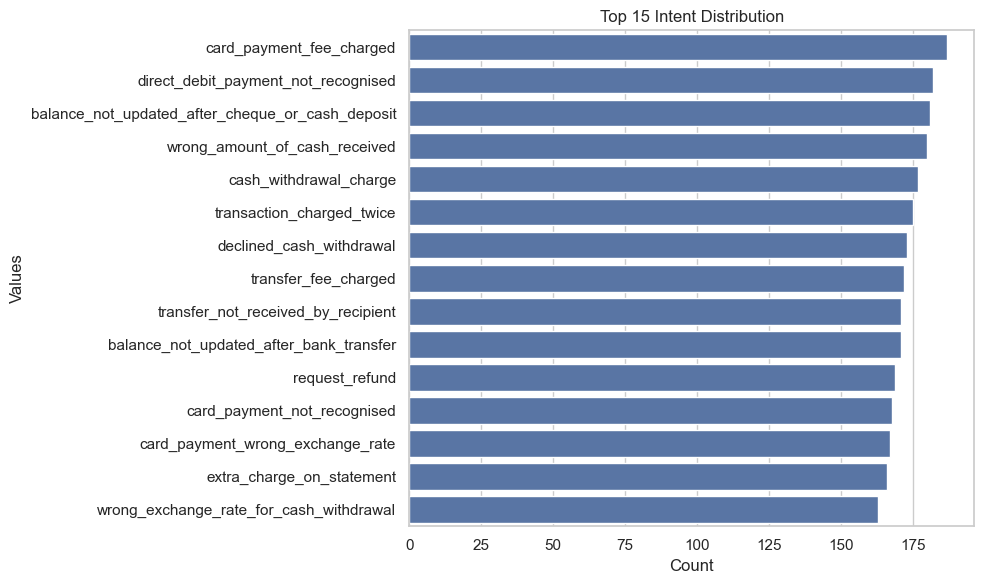

In [262]:
plt.figure(figsize=(10, 6))
top15 = intent_count.head(15)
sns.barplot(x=top15.values, y=top15.index)
plt.xlabel('Count')
plt.ylabel('Values')
plt.title('Top 15 Intent Distribution')
plt.tight_layout()
plt.show()

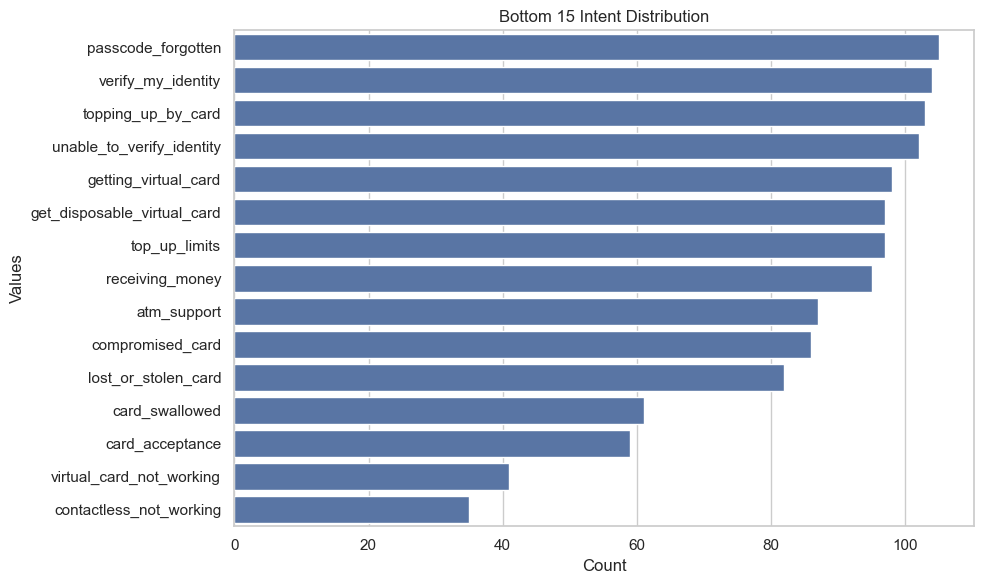

In [263]:
#bottom 15
plt.figure(figsize=(10, 6))
bottom15 = intent_count.tail(15)
sns.barplot(x=bottom15.values, y=bottom15.index)
plt.xlabel('Count')
plt.ylabel('Values')
plt.title('Bottom 15 Intent Distribution')
plt.tight_layout()
plt.show()

In [218]:
print(f"Most common intent: {intent_count.index[0]} ({intent_count.values[0]} samples)")
print(f"Least common intent: {intent_count.index[-1]} ({intent_count.values[-1]} samples)")

Most common intent: card_payment_fee_charged (187 samples)
Least common intent: contactless_not_working (35 samples)


In [219]:
train_df['char_count'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
train_df['token_count'] = train_df['tokLem_text'].apply(len)
train_df.head()

,text,category,preprocessed_text,tokLem_text,processed_txt,char_count,word_count,token_count
0,I am still waiting on my card?,card_arrival,i am still waiting on my card,"[still, waiting, card]",still waiting card,30,7,3
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival,what can i do if my card still hasnt arrived after 2 weeks,"[card, still, hasnt, arrived, week]",card still hasnt arrived week,60,13,5
2,I have been waiting over a week. Is the card still coming?,card_arrival,i have been waiting over a week is the card still coming,"[waiting, week, card, still, coming]",waiting week card still coming,58,12,5
3,Can I track my card while it is in the process of delivery?,card_arrival,can i track my card while it is in the process of delivery,"[track, card, process, delivery]",track card process delivery,59,13,4
4,"How do I know if I will get my card, or if it is lost?",card_arrival,how do i know if i will get my card or if it is lost,"[know, get, card, lost]",know get card lost,54,15,4


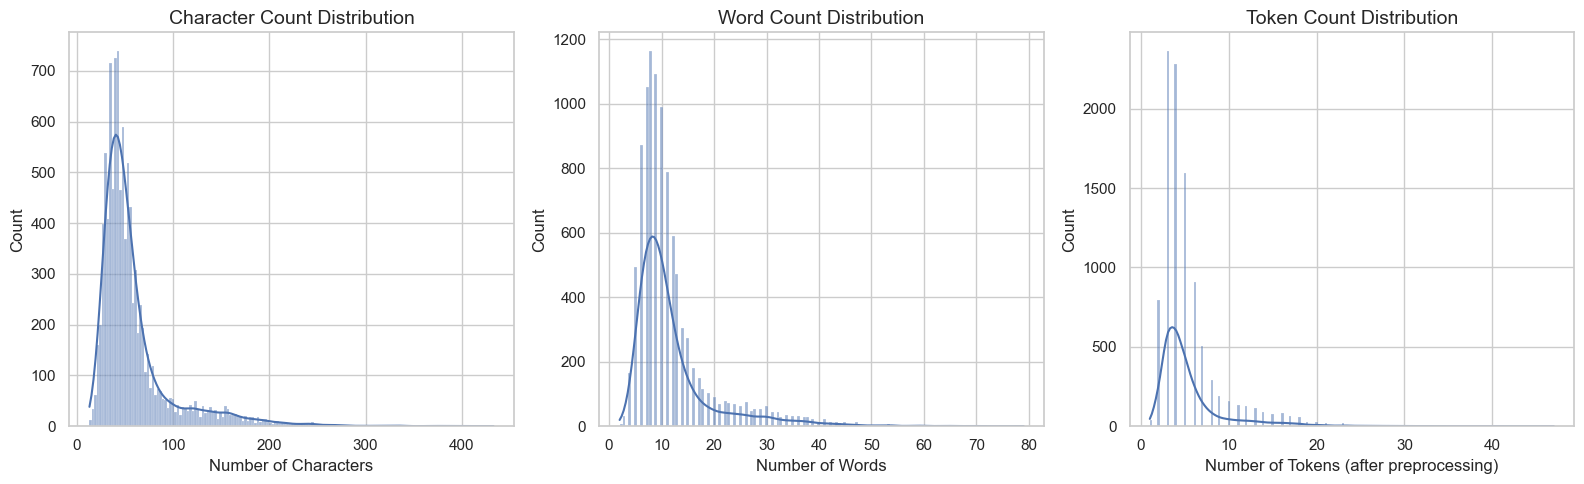

In [264]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Character count
sns.histplot(data=train_df, x='char_count', kde=True, ax=axes[0])
axes[0].set_title('Character Count Distribution', fontsize=14)
axes[0].set_xlabel('Number of Characters', fontsize=12)

# Word count
sns.histplot(data=train_df, x='word_count', kde=True, ax=axes[1])
axes[1].set_title('Word Count Distribution', fontsize=14)
axes[1].set_xlabel('Number of Words', fontsize=12)

# Token count (after preprocessing)
sns.histplot(data=train_df, x='token_count', kde=True, ax=axes[2])
axes[2].set_title('Token Count Distribution', fontsize=14)
axes[2].set_xlabel('Number of Tokens (after preprocessing)', fontsize=12)

plt.tight_layout()
plt.show()

In [221]:
#length of quey depending upon each category

avg_query_length = train_df.groupby('category')['word_count'].mean().sort_values(ascending=False)

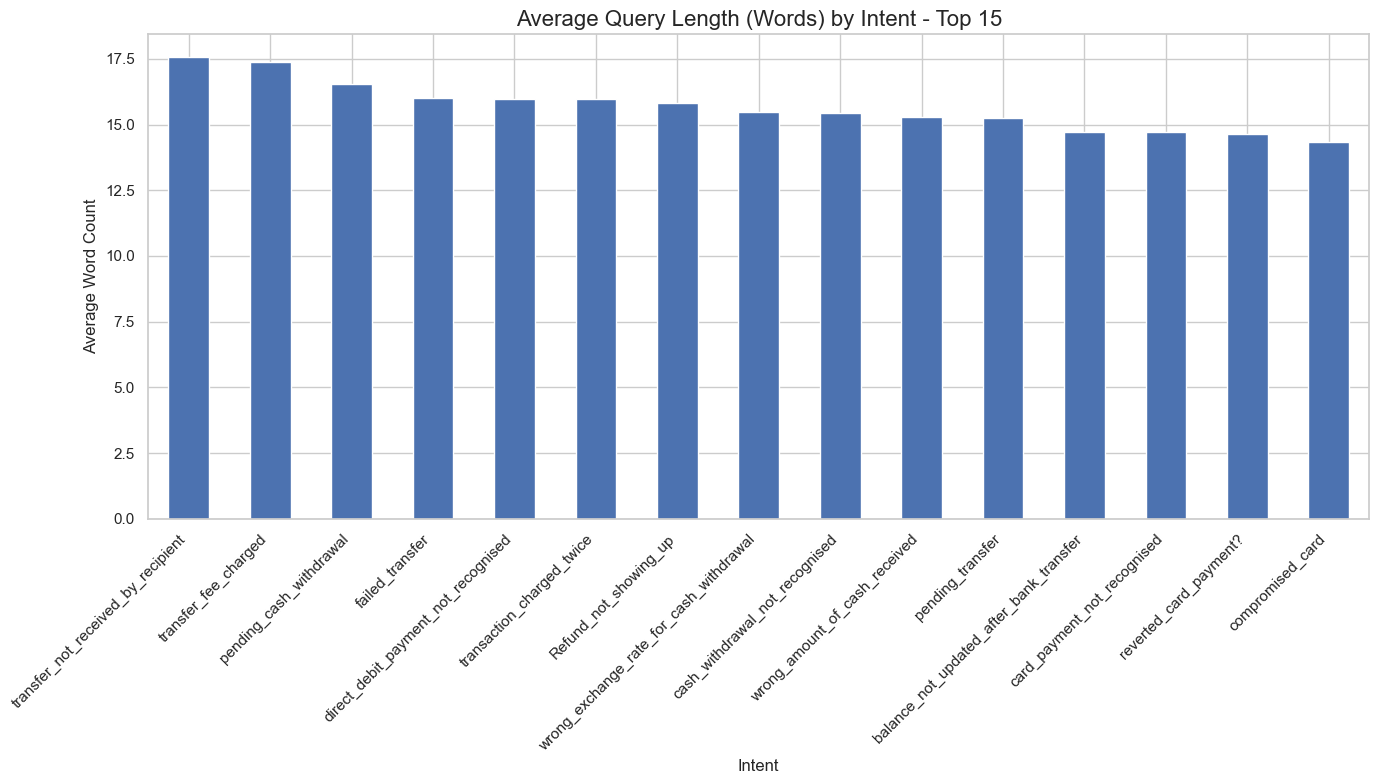

In [265]:
plt.figure(figsize=(14, 8))
avg_query_length.head(15).plot(kind='bar')
plt.title('Average Query Length (Words) by Intent - Top 15', fontsize=16)
plt.xlabel('Intent', fontsize=12)
plt.ylabel('Average Word Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [267]:
all_words = [word for tokens in train_df['tokLem_text'] for word in tokens]
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
common_words

[('card', 2967),
 ('account', 1368),
 ('transfer', 1231),
 ('money', 1132),
 ('payment', 842),
 ('get', 816),
 ('need', 736),
 ('cash', 690),
 ('top', 616),
 ('exchange', 589),
 ('fee', 584),
 ('atm', 533),
 ('charged', 528),
 ('please', 514),
 ('app', 469),
 ('transaction', 447),
 ('use', 427),
 ('pending', 424),
 ('currency', 400),
 ('charge', 395)]

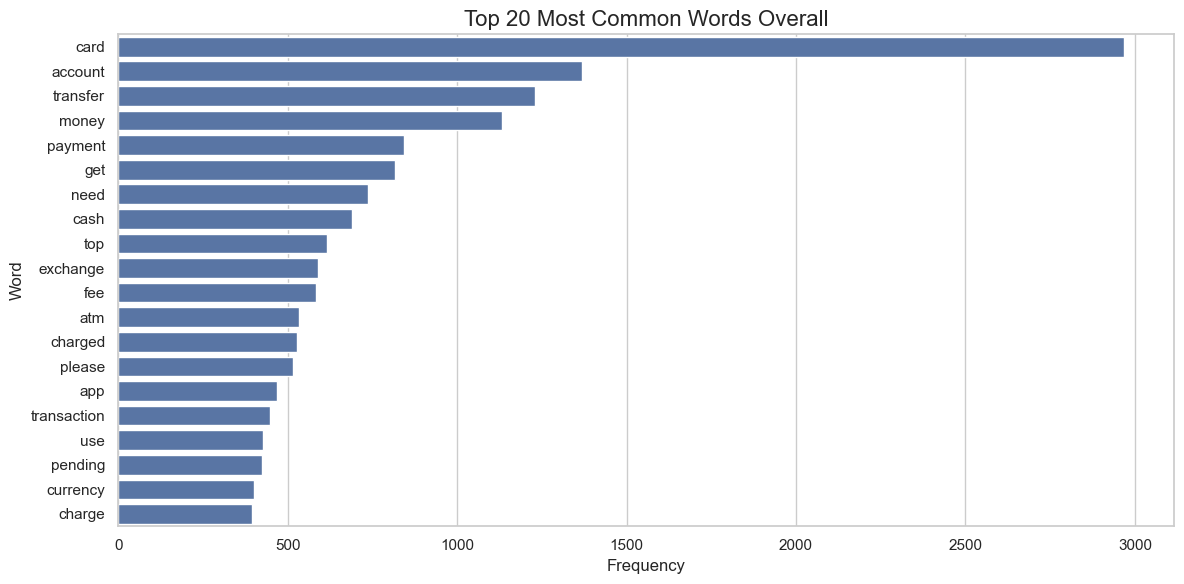

In [268]:
plt.figure(figsize=(12, 6))
words, counts = zip(*common_words)
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Most Common Words Overall', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

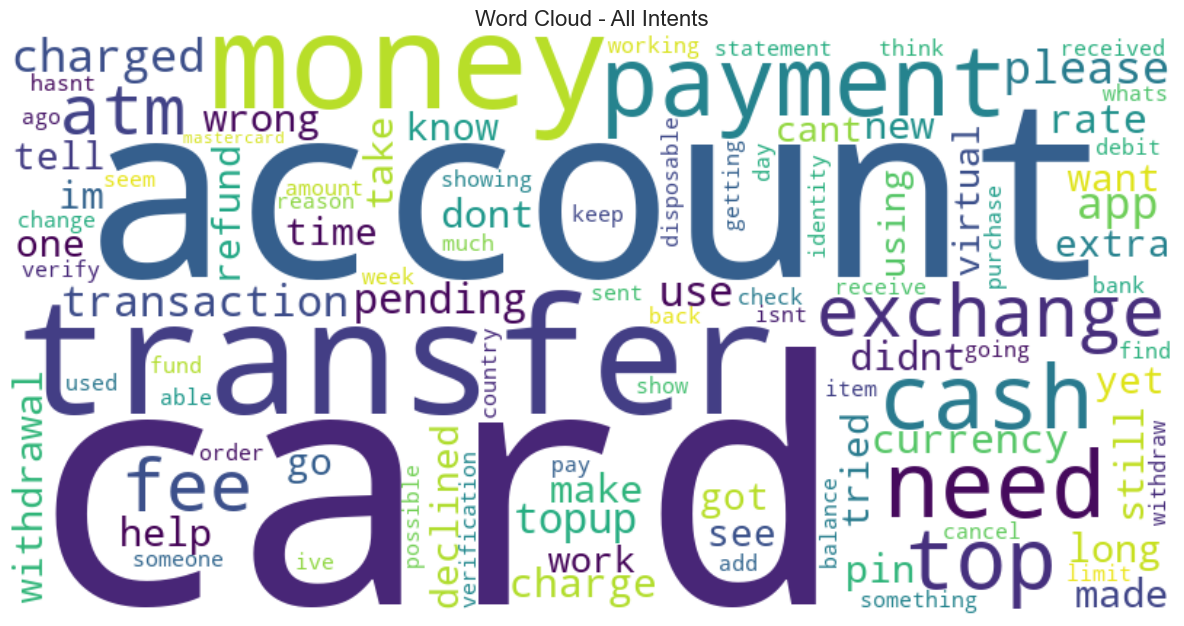

In [269]:
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100,
                     collocations=False, colormap='viridis').generate(' '.join(all_words))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Intents', fontsize=16)
plt.tight_layout()
plt.show()

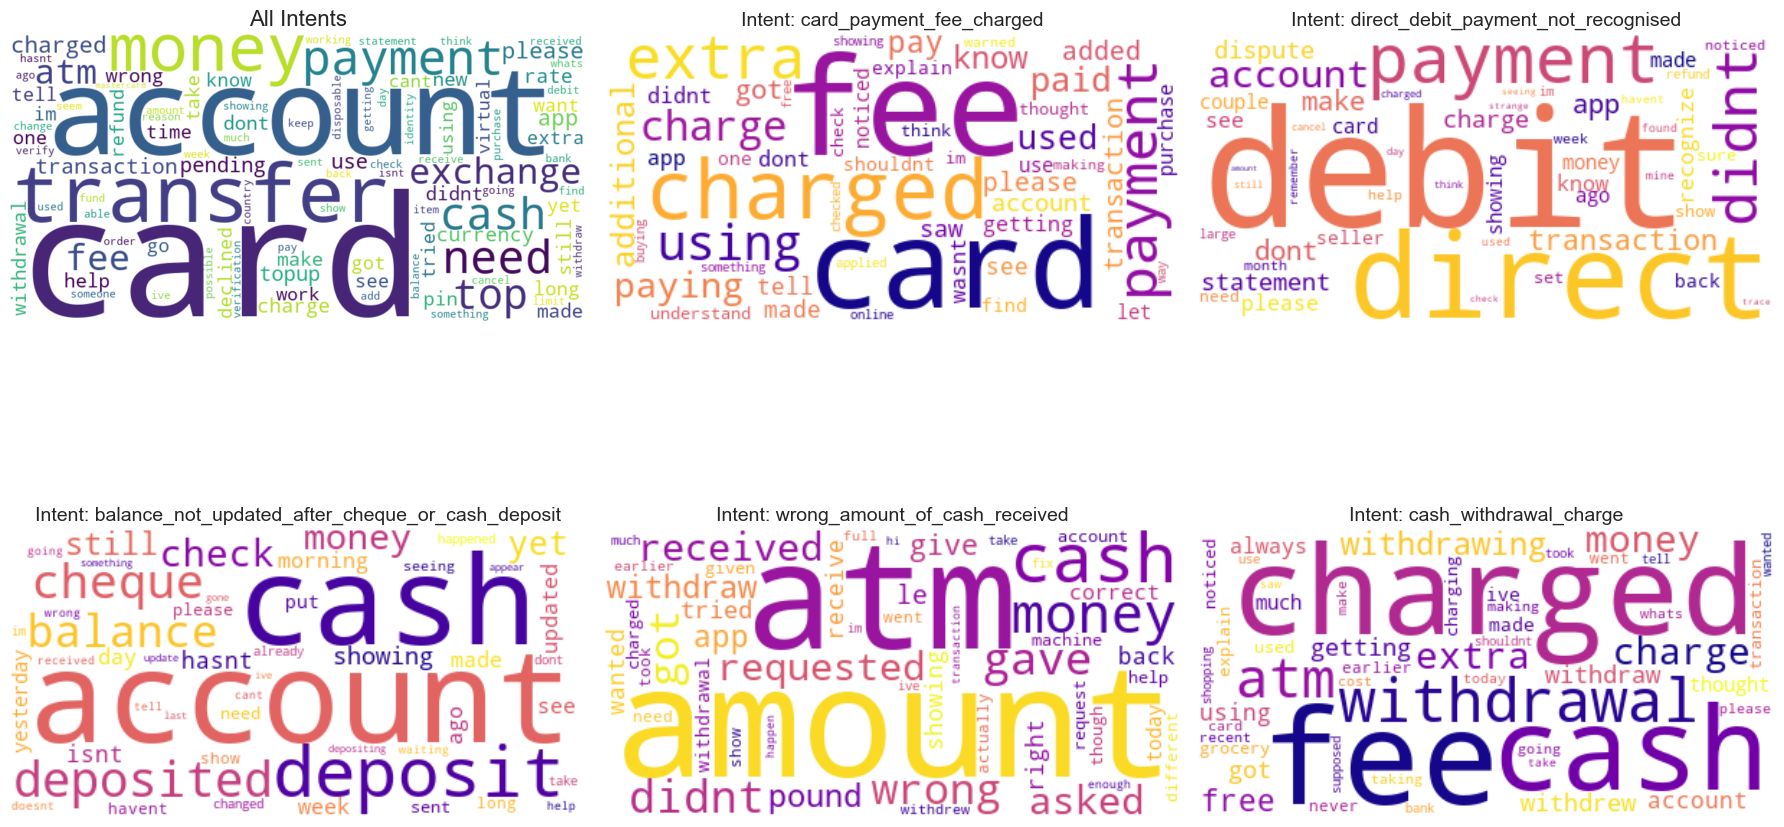

In [270]:
top_5_intents = intent_count.head(5).index.tolist()
# for intent in top_5_intents:
#     intent_words = [word for tokens in train_df[train_df['category'] == intent]['tokLem_text'] for word in tokens]
#     
#     if intent_words:
#         intent_wordcloud = WordCloud(
#             width=800, height=400, 
#             background_color='white', 
#             max_words=50,
#             collocations=False, 
#             colormap='plasma'
#         ).generate(' '.join(intent_words))
#         plt.figure(figsize=(10, 6))
#         plt.imshow(intent_wordcloud, interpolation='bilinear')
#         plt.axis('off')
#         plt.title(f'Word Cloud - Intent: {intent}', fontsize=16)
#         plt.tight_layout()
#         plt.show()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('All Intents', fontsize=16)
for i, intent in enumerate(top_5_intents):
    if i >= 5:  # Only showing 5 intents
        break
        
    intent_words = [word for tokens in train_df[train_df['category'] == intent]['tokLem_text'] for word in tokens]
    if intent_words:
        intent_wordcloud = WordCloud(
            width=400, height=200, 
            background_color='white', 
            max_words=50,
            collocations=False, 
            colormap='plasma'
        ).generate(' '.join(intent_words))
        
        axes[i+1].imshow(intent_wordcloud, interpolation='bilinear')
        axes[i+1].axis('off')
        axes[i+1].set_title(f'Intent: {intent}', fontsize=14)

plt.tight_layout()
plt.show()

In [227]:
intents = sorted(train_df['category'].unique())
intent_texts = {}
for intent in intents:
    intent_texts[intent] = ' '.join(train_df[train_df['category'] == intent]['text'].tolist())
intent_df = pd.DataFrame({
'intent': list(intent_texts.keys()),
'text': list(intent_texts.values())
})
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.95, max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(intent_df['text'])

Top intent pairs by TF-IDF similarity:
compromised_card & transfer_into_account: 0.9829
direct_debit_payment_not_recognised & wrong_amount_of_cash_received: 0.9544
transaction_charged_twice & transfer_into_account: 0.9525
compromised_card & transaction_charged_twice: 0.9360
age_limit & apple_pay_or_google_pay: 0.9296
card_delivery_estimate & edit_personal_details: 0.9178
disposable_card_limits & wrong_amount_of_cash_received: 0.9099
direct_debit_payment_not_recognised & disposable_card_limits: 0.8962
failed_transfer & pending_top_up: 0.8637
edit_personal_details & reverted_card_payment?: 0.8559


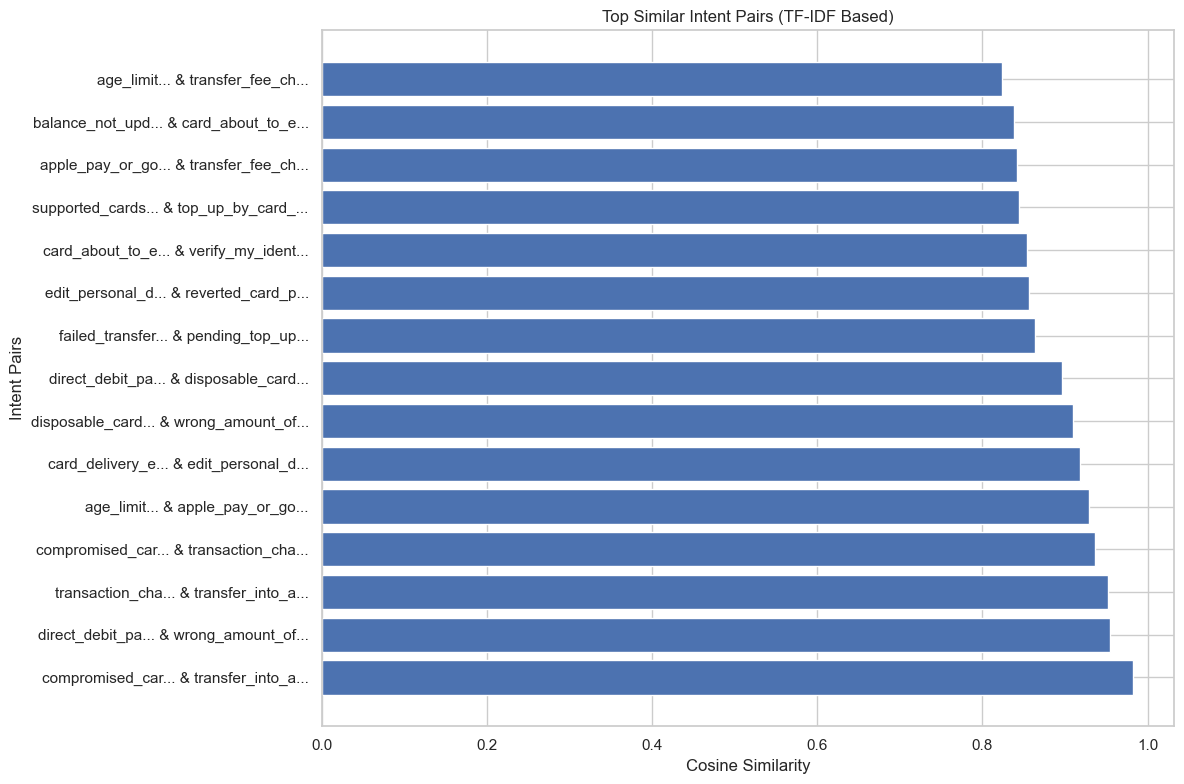

In [271]:
from sklearn.metrics.pairwise import cosine_similarity
#########I have used cosine similarity
tfidf_similarity = cosine_similarity(tfidf_matrix)
tfidf_sim_df = pd.DataFrame(tfidf_similarity, index=intent_df['intent'], columns=intent_df['intent'])
def get_top_similar_pairs(sim_matrix, labels, top_n=15):
    pairs = []
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            pairs.append((labels[i], labels[j], sim_matrix[i, j]))
    
    pairs.sort(key=lambda x: x[2], reverse=True)
    
    return pairs[:top_n]

top_tfidf_pairs = get_top_similar_pairs(tfidf_similarity, intent_df['intent'].tolist())

print("Top intent pairs by TF-IDF similarity:")
for intent1, intent2, score in top_tfidf_pairs[:10]:
    print(f"{intent1} & {intent2}: {score:.4f}")

plt.figure(figsize=(12, 8))
pair_names = [f"{i1[:15]}... & {i2[:15]}..." for i1, i2, _ in top_tfidf_pairs]
similarity_scores = [score for _, _, score in top_tfidf_pairs]

plt.barh(pair_names, similarity_scores)
plt.xlabel('Cosine Similarity')
plt.ylabel('Intent Pairs')
plt.title('Top Similar Intent Pairs (TF-IDF Based)')
plt.tight_layout()
plt.show()

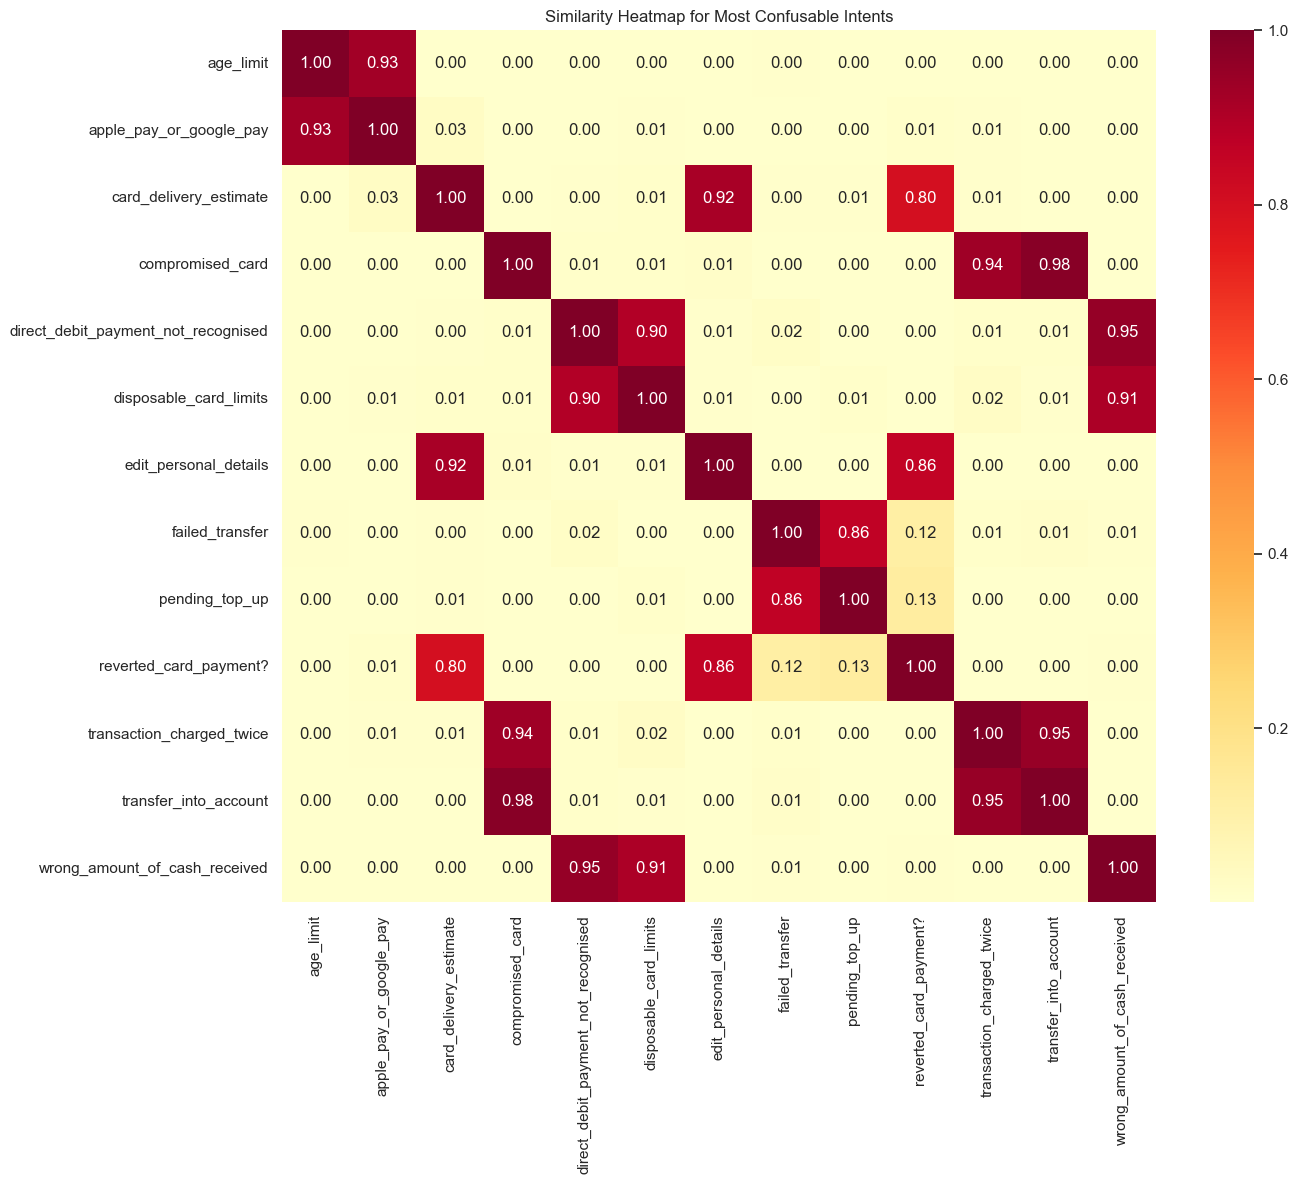

In [282]:
####Visulaized similarity using heatmap
%matplotlib inline

top_intents = set()
for intent1, intent2, _ in top_tfidf_pairs[:10]:
    top_intents.add(intent1)
    top_intents.add(intent2)
top_intents = sorted(list(top_intents))
indices = [list(intent_df['intent']).index(intent) for intent in top_intents]
top_sim_matrix = tfidf_similarity[np.ix_(indices, indices)]
plt.figure(figsize=(14, 12))
sns.heatmap(
    top_sim_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", 
    xticklabels=top_intents,
    yticklabels=top_intents
)
plt.title('Similarity Heatmap for Most Confusable Intents')
plt.tight_layout()
plt.show()

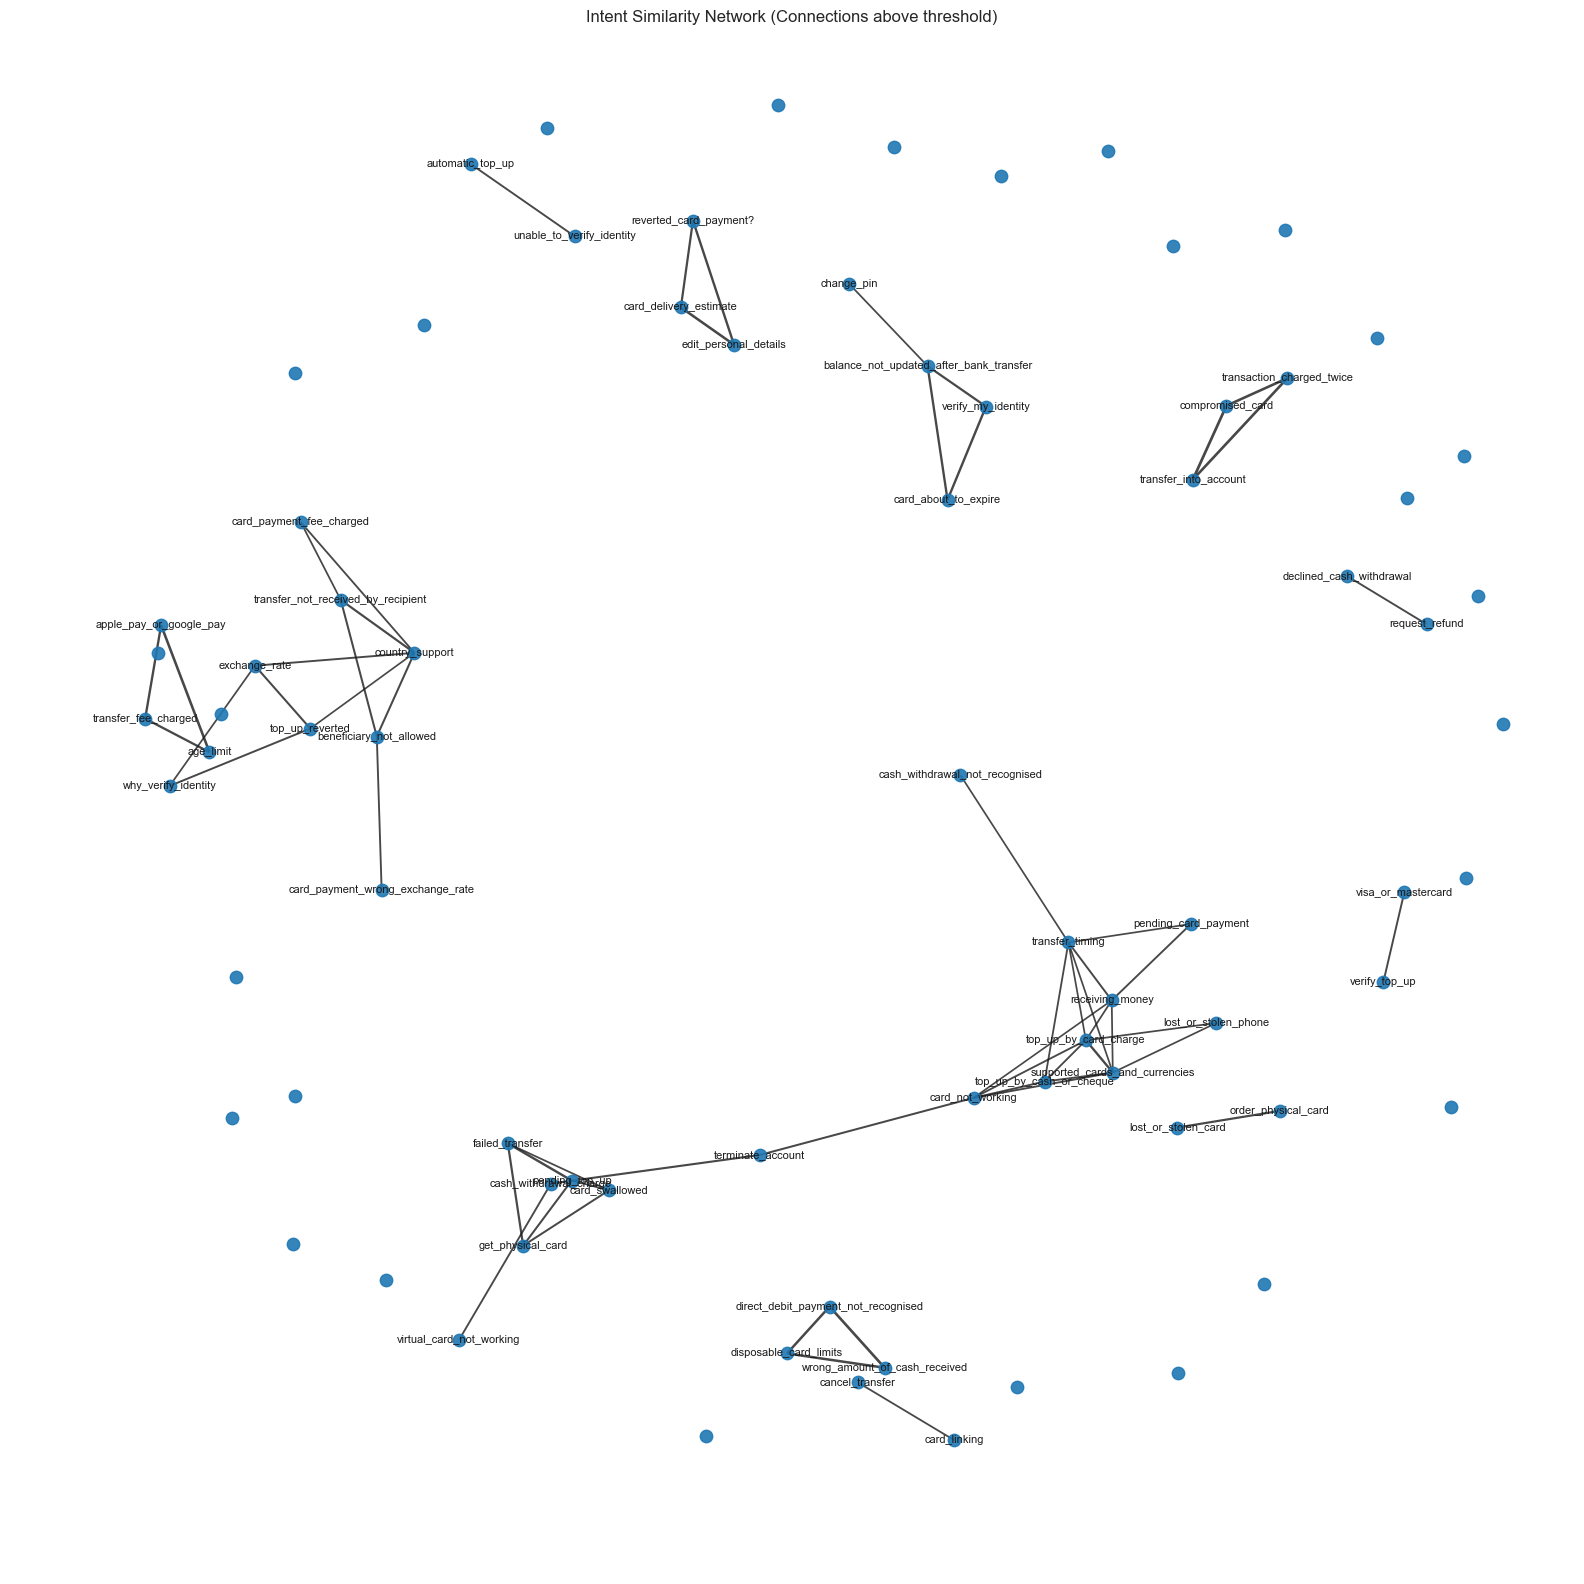

In [273]:
#Netwrk graph
import networkx as nx
threshold = 0.6#########will show graphs which have similarity > 0.6
G = nx.Graph()
for intent in intent_df['intent']:
    G.add_node(intent)
for i, intent1 in enumerate(intent_df['intent']):
    for j, intent2 in enumerate(intent_df['intent']):
        if i < j and tfidf_similarity[i, j] > threshold:
            G.add_edge(intent1, intent2, weight=tfidf_similarity[i, j])
plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, k=0.3, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=80, alpha=0.9)
edge_weights = [G[u][v]['weight'] * 2 for u, v in G.edges()]#############based on similarity setting edge thickness
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.8)

# Only show labels for connected nodes
connected_nodes = [node for node in G.nodes() if G.degree(node) > 0]
node_labels = {node: node for node in connected_nodes}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

plt.title('Intent Similarity Network (Connections above threshold)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [231]:
###########overlap with different intents
for intent1, intent2, score in top_tfidf_pairs[:5]:
    text1 = ' '.join(train_df[train_df['category'] == intent1]['processed_txt'])
    text2 = ' '.join(train_df[train_df['category'] == intent2]['processed_txt'])
    tokens1 = text1.split()
    tokens2 = text2.split()
    ###############based on frequency
    from collections import Counter
    freq1 = Counter(tokens1)
    freq2 = Counter(tokens2)
    
    common_words = set(freq1.keys()).intersection(set(freq2.keys()))#####getting top 10 common words with high frequency
    top_shared = sorted([(word, freq1[word] + freq2[word]) for word in common_words], 
                        key=lambda x: x[1], reverse=True)[:10]
    
    print(f"\nShared vocabulary for {intent1} & {intent2} (similarity: {score:.4f}):")
    for word, freq in top_shared:
        print(f"  {word}: {freq} occurrences")




Shared vocabulary for verify_my_identity & why_verify_identity (similarity: 0.9032):
  identity: 167 occurrences
  need: 60 occurrences
  verify: 57 occurrences
  verification: 47 occurrences
  check: 43 occurrences
  use: 33 occurrences
  account: 30 occurrences
  id: 16 occurrences
  document: 13 occurrences
  step: 11 occurrences

Shared vocabulary for get_physical_card & pin_blocked (similarity: 0.8842):
  pin: 214 occurrences
  card: 53 occurrences
  get: 31 occurrences
  help: 21 occurrences
  find: 20 occurrences
  number: 17 occurrences
  need: 12 occurrences
  dont: 9 occurrences
  cant: 8 occurrences
  app: 6 occurrences

Shared vocabulary for getting_virtual_card & virtual_card_not_working (similarity: 0.8609):
  card: 139 occurrences
  virtual: 136 occurrences
  get: 38 occurrences
  cant: 9 occurrences
  use: 7 occurrences
  received: 6 occurrences
  please: 5 occurrences
  got: 4 occurrences
  make: 4 occurrences
  help: 3 occurrences

Shared vocabulary for disposable_ca

In [232]:
# ####chord diagram 
# try:
#     import holoviews as hv
#     from holoviews import opts, dim
#     hv.extension('matplotlib')
#     links = []
#     for intent1, intent2, score in top_tfidf_pairs[:20]:
#         if score > 0.5:########connections which have score greater tha 0.5
#             links.append((intent1, intent2, score))
#     chord = hv.Chord(links)
#     chord.opts(
#         opts.Chord(
#             cmap='Category20',
#             edge_cmap='Blues',
#             edge_color=dim('weight').norm(),
#             labels='index',
#             node_color=dim('index').str(),
#         )
#     )
#     hv.save(chord, 'intent_chord_diagram.png')
#     print("Chord diagram saved as 'intent_chord_diagram.png'")
#     chord
# except ImportError:
#     print("Holoviews package not available for chord diagram - skipping this visualization")


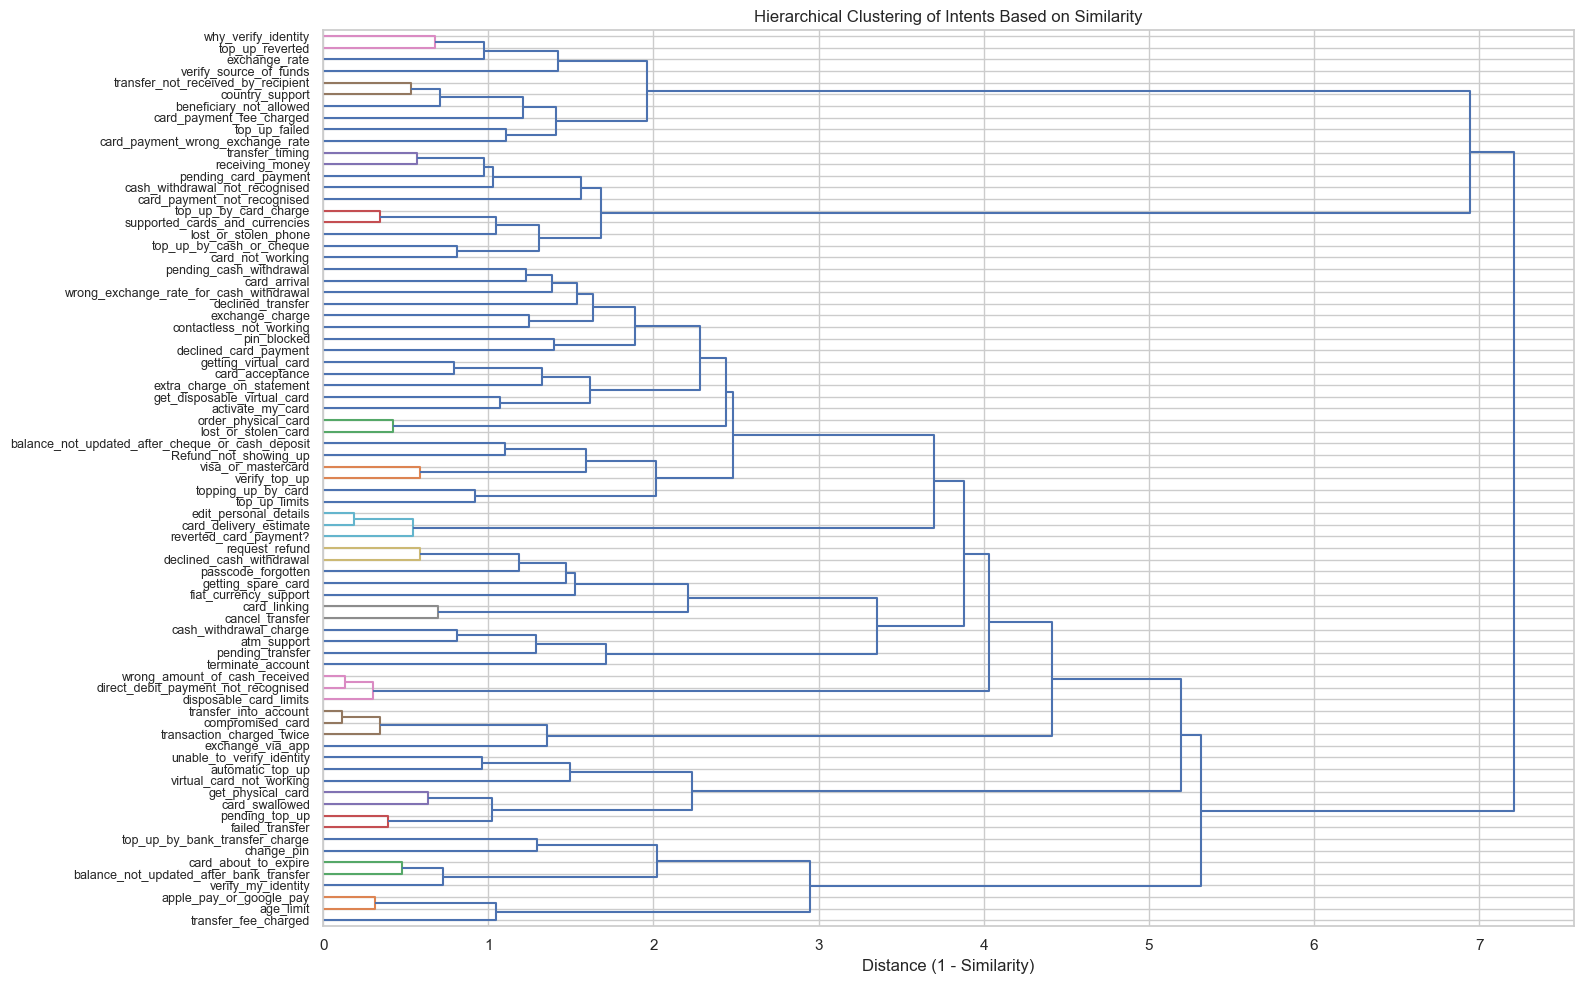

In [274]:
#Hierarchical clustering of intents based on similarity
%matplotlib inline
from scipy.cluster.hierarchy import dendrogram, linkage
distance_matrix = 1 - tfidf_similarity
Z = linkage(distance_matrix, 'ward')#####hirearichal clustering

plt.figure(figsize=(16, 10))
dendrogram(
    Z,
    labels=intent_df['intent'].tolist(),
    orientation='right',
    leaf_font_size=9,
    color_threshold=0.7
)
plt.title('Hierarchical Clustering of Intents Based on Similarity')
plt.xlabel('Distance (1 - Similarity)')
plt.tight_layout()
plt.show()

In [280]:
#############now next I wanted to check most important keywords in each category, but don't want the ones which are very common in all documents. So, I am using TF-IDF. Like for intent- account opening - > keyword opening will be discriminative

from collections import defaultdict
import matplotlib.cm as cm

intent_texts = {}
for intent in train_df['category'].unique():
    intent_texts[intent] = ' '.join(train_df[train_df['category'] == intent]['processed_txt'].values)


tfidf_vectorizer = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.7)#####again taking min_df and max_df for checking for  minimum and max document frequency threshold
tfidf_matrix = tfidf_vectorizer.fit_transform([text for text in intent_texts.values()])
feature_names = tfidf_vectorizer.get_feature_names_out()
####getting top 10 keywords for analysis purpose
n_top_keywords = 10
keywords_by_intent = {}

for i, intent in enumerate(intent_texts.keys()):
    tfidf_scores = tfidf_matrix[i].toarray()[0]
    top_indices = tfidf_scores.argsort()[-n_top_keywords:][::-1]
    keywords_by_intent[intent] = [(feature_names[idx], tfidf_scores[idx]) for idx in top_indices]


top_intents = train_df['category'].value_counts().head(20).index.tolist()



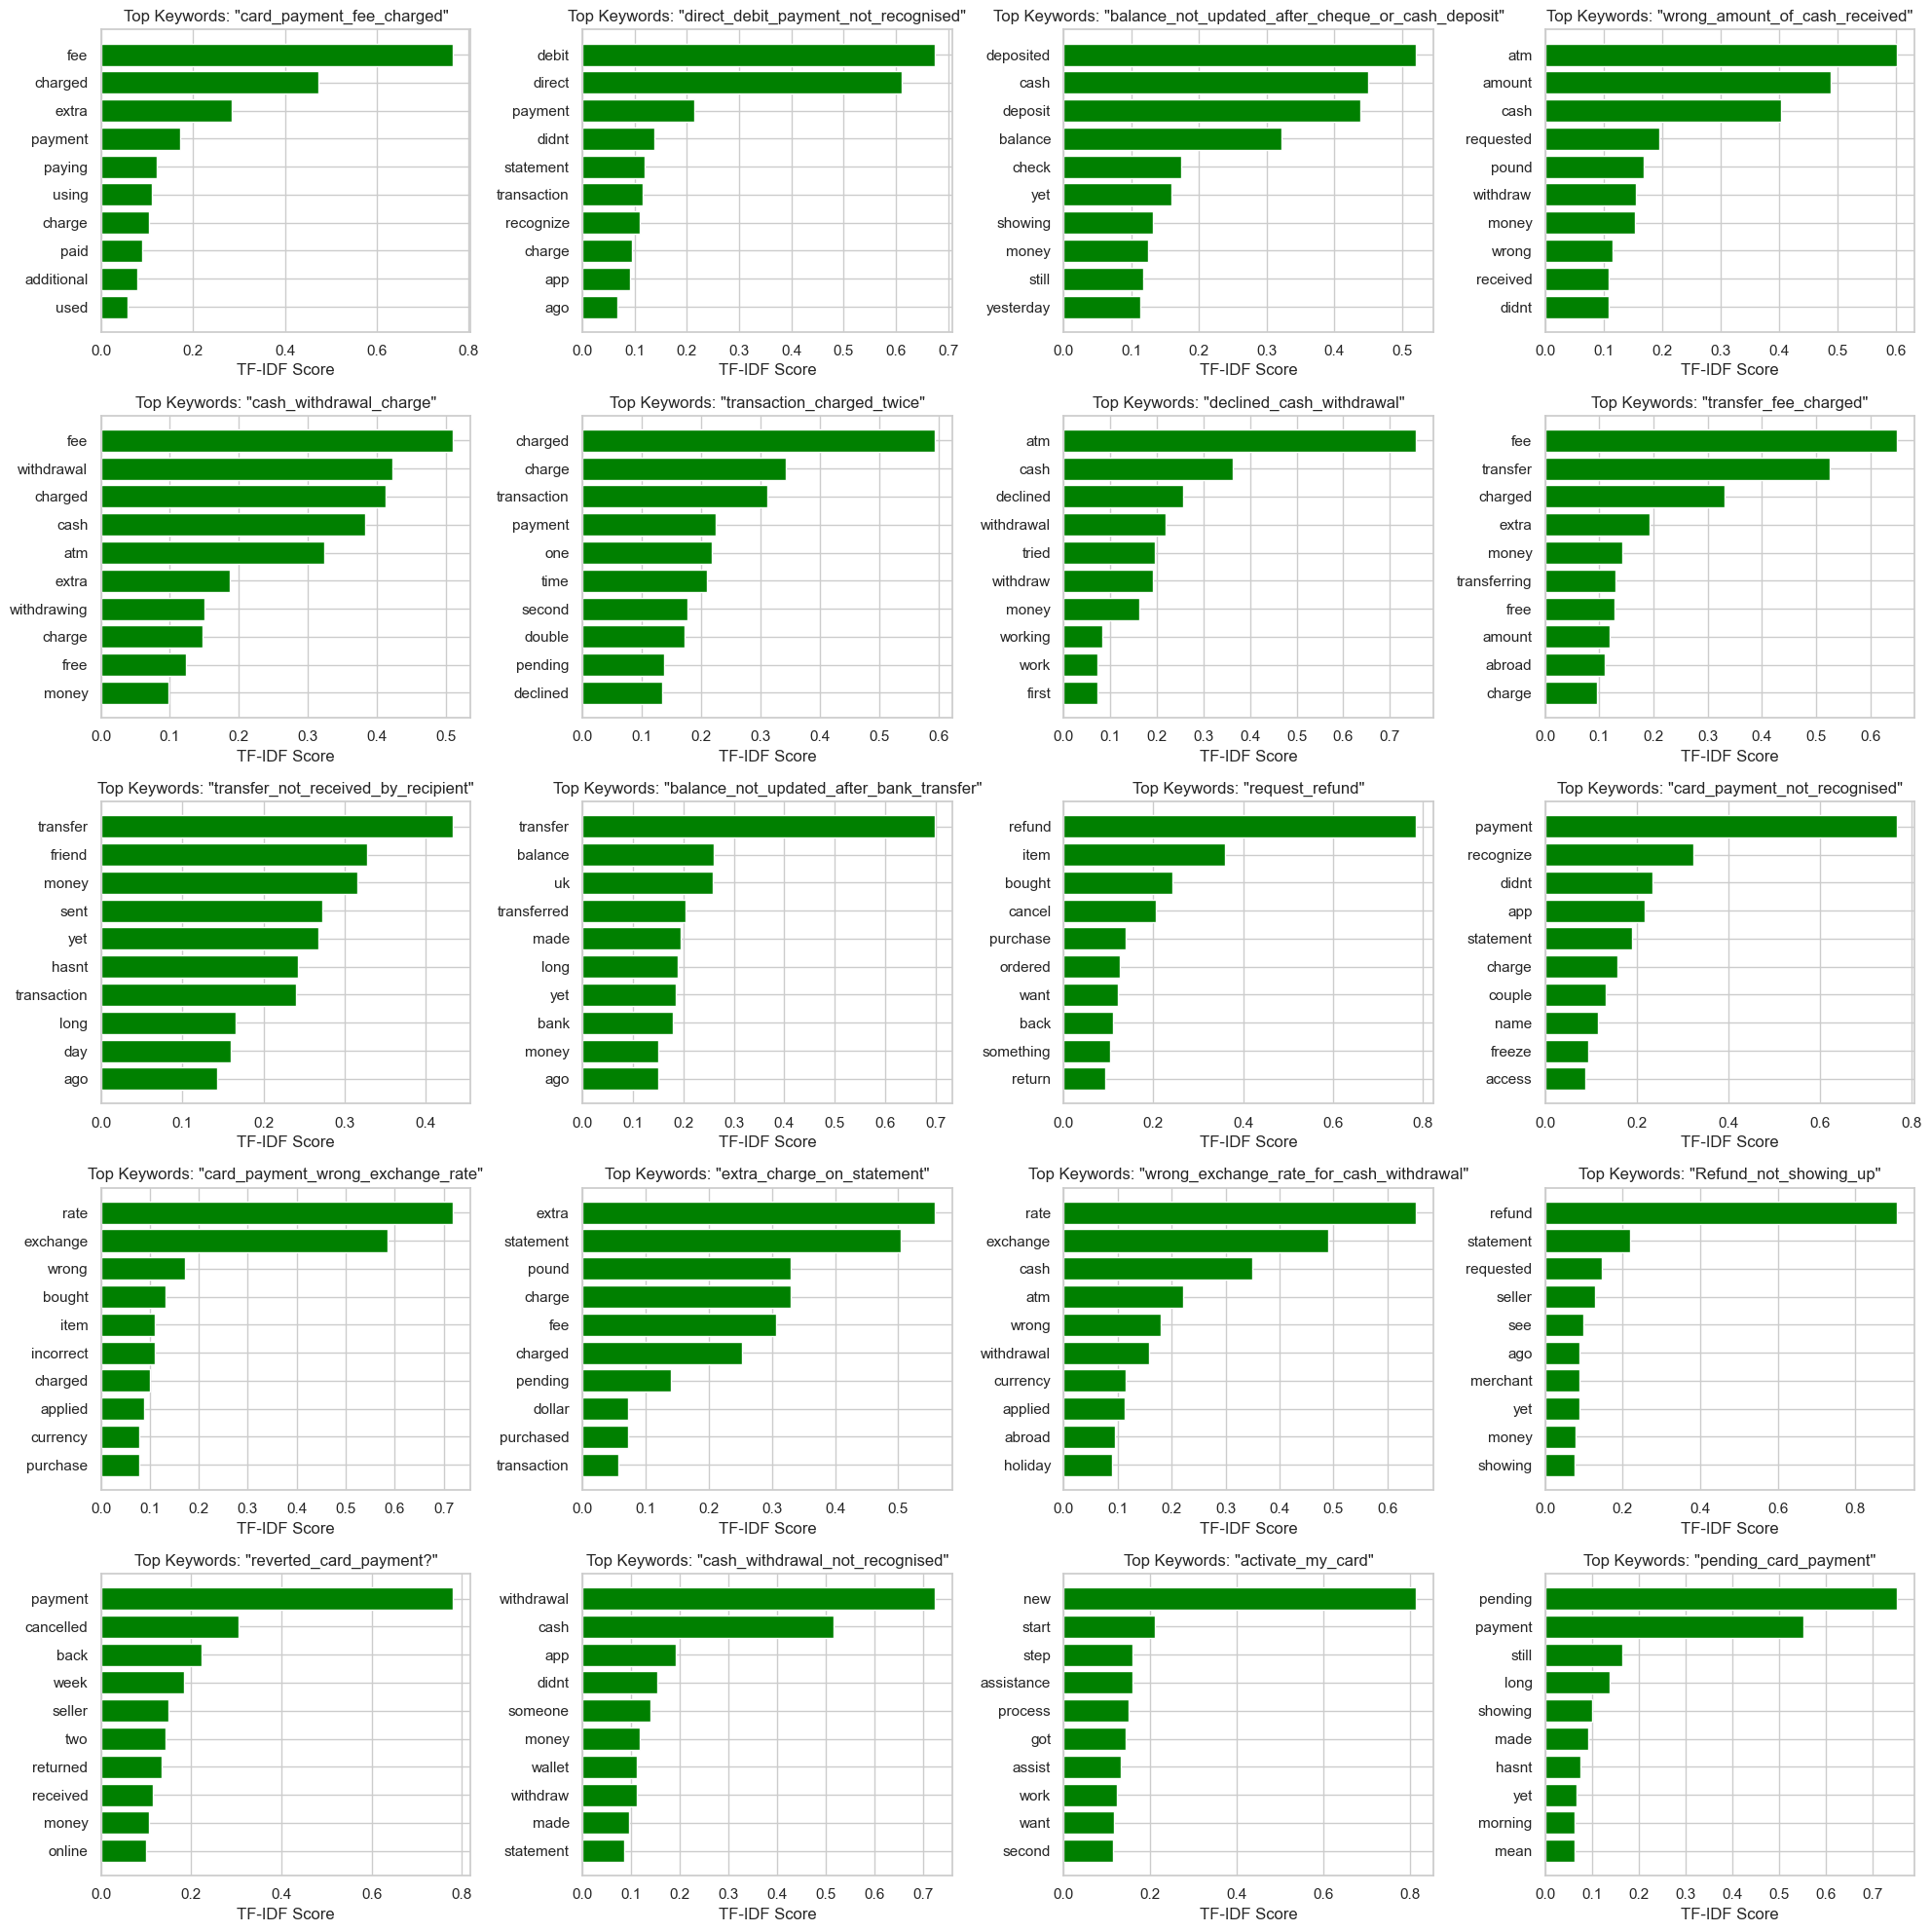

In [281]:
fig, axs = plt.subplots(5, 4, figsize=(20, 20))
axs = axs.flatten()

for i, intent in enumerate(top_intents):
    keywords, scores = zip(*keywords_by_intent[intent])
    axs[i].barh(keywords[::-1], scores[::-1], color='green')
    axs[i].set_title(f'Top Keywords: "{intent}"')
    axs[i].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()
plt.close()


In [236]:

keyword_distribution = defaultdict(list)

for intent, keywords in keywords_by_intent.items():
    for keyword, score in keywords:
        keyword_distribution[keyword].append((intent, score))

####Multiple intent keywords
shared_keywords = {k: v for k, v in keyword_distribution.items() if len(v) > 1}
shared_keywords_sorted = sorted(shared_keywords.items(), key=lambda x: len(x[1]), reverse=True)

print("\nTop shared keywords across intents:")
for keyword, intent_scores in shared_keywords_sorted[:20]:
    intents = [intent for intent, _ in intent_scores]
    print(f"Keyword '{keyword}' appears in {len(intents)} intents: {', '.join(intents[:5])}" + 
          (f" and {len(intents)-5} more..." if len(intents) > 5 else ""))




Top shared keywords across intents:
Keyword 'money' appears in 27 intents: pending_cash_withdrawal, fiat_currency_support, automatic_top_up, exchange_via_app, top_up_by_bank_transfer_charge and 22 more...
Keyword 'use' appears in 16 intents: fiat_currency_support, card_not_working, age_limit, contactless_not_working, supported_cards_and_currencies and 11 more...
Keyword 'transfer' appears in 14 intents: exchange_rate, top_up_by_bank_transfer_charge, cancel_transfer, transfer_not_received_by_recipient, topping_up_by_card and 9 more...
Keyword 'top' appears in 13 intents: automatic_top_up, top_up_by_bank_transfer_charge, pending_top_up, top_up_limits, supported_cards_and_currencies and 8 more...
Keyword 'work' appears in 12 intents: exchange_rate, card_not_working, contactless_not_working, passcode_forgotten, declined_cash_withdrawal and 7 more...
Keyword 'charge' appears in 12 intents: extra_charge_on_statement, top_up_by_bank_transfer_charge, card_payment_fee_charged, card_payment_not

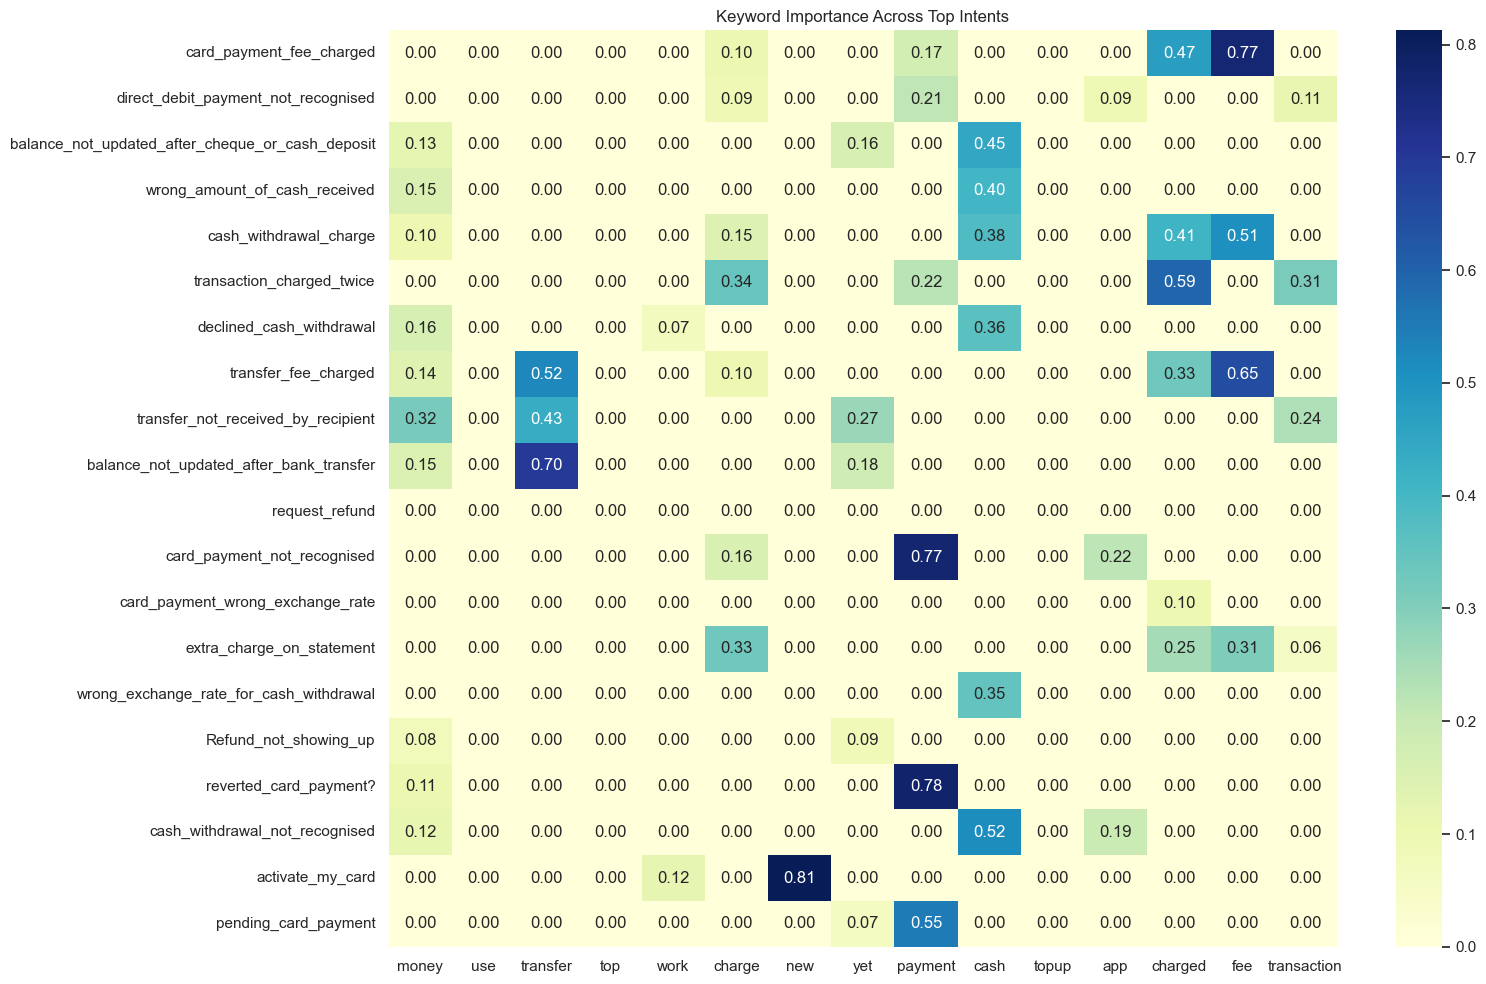

In [278]:

top_shared_keywords = [k for k, _ in shared_keywords_sorted[:15]]
selected_intents = top_intents
keyword_importance = np.zeros((len(selected_intents), len(top_shared_keywords)))

for i, intent in enumerate(selected_intents):
    for j, keyword in enumerate(top_shared_keywords):
        for kw, score in keywords_by_intent[intent]:
            if kw == keyword:
                keyword_importance[i, j] = score
                break

plt.figure(figsize=(16, 10))
sns.heatmap(
    keyword_importance,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=top_shared_keywords,
    yticklabels=selected_intents
)
plt.title('Keyword Importance Across Top Intents')
plt.tight_layout()
plt.show()
plt.close()



In [238]:
#############next I am doing uniqueness analysis, as it shows which keyword is particulary distinctive for that category....which keyword is unique to a particular intent.
keyword_uniqueness = {}
keywords_by_intent = defaultdict(list)

for keyword in feature_names:
    intent_scores = defaultdict(float)
    
    for i, intent in enumerate(intent_texts.keys()):
        keyword_idx = np.where(feature_names == keyword)[0]
        if len(keyword_idx) > 0:
            intent_scores[intent] = tfidf_matrix[i, keyword_idx[0]]
    if sum(intent_scores.values()) == 0:
        continue
    max_intent, max_score = max(intent_scores.items(), key=lambda x: x[1])
    total_score = sum(intent_scores.values())
    uniqueness = max_score / total_score if total_score > 0 else 0
    keywords_by_intent[max_intent].append((keyword, uniqueness, max_score))
    keyword_uniqueness[keyword] = (uniqueness, list(intent_scores.items()))
for intent in keywords_by_intent:
    keywords_by_intent[intent] = sorted(keywords_by_intent[intent], 
                                        key=lambda x: x[1], 
                                        reverse=True)
print("\nDistinctive Keywords by Intent")
for intent in sorted(keywords_by_intent.keys()):
    intent_keywords = keywords_by_intent[intent]
    
    print(f"\nIntent: {intent}")
    print(f"Number of distinctive keywords: {len(intent_keywords)}")
    top_keywords = intent_keywords[:10]
    for keyword, uniqueness, score in top_keywords:
        print(f"  {keyword}: uniqueness={uniqueness:.4f}, tf-idf={score:.4f}")
        






Distinctive Keywords by Intent

Intent: Refund_not_showing_up
Number of distinctive keywords: 3
  refund: uniqueness=0.5041, tf-idf=0.9076
  checking: uniqueness=0.3119, tf-idf=0.0480
  said: uniqueness=0.2095, tf-idf=0.0263

Intent: activate_my_card
Number of distinctive keywords: 13
  hit: uniqueness=0.7422, tf-idf=0.0760
  assistance: uniqueness=0.5874, tf-idf=0.1577
  start: uniqueness=0.5461, tf-idf=0.2096
  thanks: uniqueness=0.4467, tf-idf=0.0363
  assist: uniqueness=0.3831, tf-idf=0.1314
  turn: uniqueness=0.3396, tf-idf=0.0363
  procedure: uniqueness=0.3099, tf-idf=0.0612
  process: uniqueness=0.2627, tf-idf=0.1488
  attempt: uniqueness=0.2478, tf-idf=0.0337
  step: uniqueness=0.2387, tf-idf=0.1595

Intent: age_limit
Number of distinctive keywords: 2
  open: uniqueness=0.8576, tf-idf=0.8270
  old: uniqueness=0.6079, tf-idf=0.3764

Intent: apple_pay_or_google_pay
Number of distinctive keywords: 1
  pay: uniqueness=0.4128, tf-idf=0.6058

Intent: atm_support
Number of distinctiv

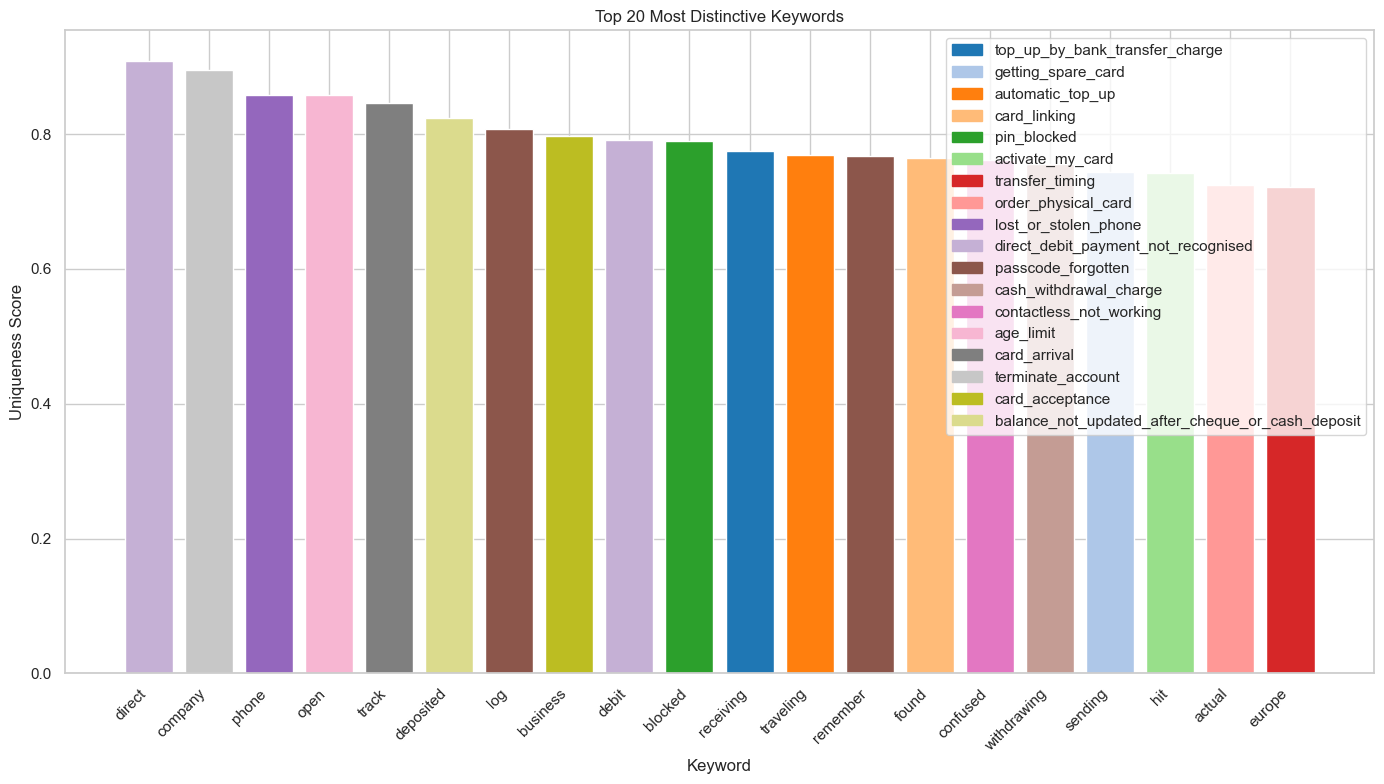

In [279]:
keyword_uniqueness_sorted = sorted(keyword_uniqueness.items(), key=lambda x: x[1][0], reverse=True)
unique_keywords = [k for k, _ in keyword_uniqueness_sorted[:20]]
unique_scores = [v[0] for _, v in keyword_uniqueness_sorted[:20]]
primary_intents = [max(v[1], key=lambda x: x[1])[0] for _, v in keyword_uniqueness_sorted[:20]]
intent_colors = {intent: color for intent, color in zip(set(primary_intents), cm.tab20.colors)}

plt.figure(figsize=(14, 8))
bars = plt.bar(unique_keywords, unique_scores, color=[intent_colors[intent] for intent in primary_intents])

handles = [plt.Rectangle((0,0),1,1, color=intent_colors[intent]) for intent in set(primary_intents)]
plt.legend(handles, set(primary_intents), loc='upper right')

plt.title('Top 20 Most Distinctive Keywords')
plt.xlabel('Keyword')
plt.ylabel('Uniqueness Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()


In [249]:
#BERT transformer model implementation for banking77 intent classification
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs('model_outputs', exist_ok=True)

label_encoder = LabelEncoder()
label_encoder.fit(train_df['category'])



Using device: cpu


LabelEncoder()

In [250]:
# train_df_sample = train_df.head(500)
# test_df_sample = test_df.head(500)
train_labels = label_encoder.transform(train_df['category'])
test_labels = label_encoder.transform(test_df['category'])
num_labels = len(label_encoder.classes_)
print(f"Number of intent classes: {num_labels}")

Number of intent classes: 77


In [251]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


MAX_LEN = 128

train_texts = train_df['processed_txt'].tolist() if 'processed_txt' in train_df.columns else train_df['text'].tolist()
test_texts = test_df['processed_txt'].tolist() if 'processed_txt' in test_df.columns else test_df['text'].tolist()


# train_texts = train_df_sample['processed_txt'].tolist() if 'processed_txt' in train_df_sample.columns else train_df_sample['text'].tolist()
# test_texts = test_df_sample['processed_txt'].tolist() if 'processed_txt' in test_df_sample.columns else test_df_sample['text'].tolist()
print("Tokenizing texts...")
train_encodings = tokenizer(train_texts, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')

Tokenizing texts...


In [252]:

train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    torch.tensor(train_labels)
)

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    torch.tensor(test_labels)
)

BATCH_SIZE = 16
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [253]:

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [254]:

epochs = 3
total_steps = len(train_dataloader) * epochs
warmup_steps = int(0.1 * total_steps)  # 10% of total steps

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


In [255]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)
        
        model.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Calculate training accuracy
        preds = torch.argmax(logits, dim=1)
        correct_predictions += (preds == labels).sum().item()
        total_predictions += len(labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
        progress_bar.set_postfix({'loss': loss.item(), 'accuracy': accuracy})
        
    avg_loss = total_loss / len(dataloader)
    train_accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    
    return avg_loss, train_accuracy

In [256]:
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
    
    return predictions, true_labels

In [257]:

print("Starting training...")
best_accuracy = 0
training_stats = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    initial_params = next(model.parameters()).clone().detach()
    avg_train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, scheduler, device)
    print(f"Average training loss: {avg_train_loss:.4f}, Training accuracy: {train_accuracy:.4f}")
    
    final_params = next(model.parameters()).clone().detach()
    param_diff = torch.sum(torch.abs(final_params - initial_params)).item()
    print(f"Parameter change after epoch: {param_diff}")
    if param_diff == 0:
        print("WARNING: Model parameters did not change during training!")
    print("Evaluating on test set...")
    predictions, true_labels = evaluate(model, test_dataloader, device)
    
    predictions_array = np.array(predictions)
    true_labels_array = np.array(true_labels)
    accuracy = np.mean(predictions_array == true_labels_array)
    print(f"Test accuracy: {accuracy:.4f}")
    
    # # Count matches directly
    # matches = sum(p == t for p, t in zip(predictions, true_labels))
    # accuracy2 = matches / len(true_labels) if len(true_labels) > 0 else 0
    # print(f"Test accuracy (direct count): {accuracy2:.4f}")
    
    # Check prediction distribution
    unique_preds, pred_counts = np.unique(predictions, return_counts=True)
    print(f"Unique predictions: {len(unique_preds)} out of {num_labels} classes")
    print(f"Most common prediction: class {unique_preds[np.argmax(pred_counts)]} ({np.max(pred_counts)} times)")
    
    # Save stats and model
    training_stats.append({
        'epoch': epoch + 1,
        'training_loss': avg_train_loss,
        'training_accuracy': train_accuracy,
        'test_accuracy': accuracy
    })
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'model_outputs/best_model.pt')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'accuracy': accuracy,
            'loss': avg_train_loss,
        }, 'model_outputs/checkpoint.pt')
        print(f"Saved new best model with accuracy: {best_accuracy:.4f}")
try:
    model.load_state_dict(torch.load('model_outputs/best_model.pt', weights_only=True))
    print("Successfully loaded best model")
except FileNotFoundError:
    print("Best model file not found, using current model state")
except Exception as e:
    print(f"Error loading model: {e}")

print("\nFinal evaluation on test set...")
predictions, true_labels = evaluate(model, test_dataloader, device)

Starting training...

Epoch 1/3


Training: 100%|██████████| 626/626 [10:10:13<00:00, 58.49s/it, loss=2.39, accuracy=0.297]     


Average training loss: 3.4362, Training accuracy: 0.2974
Parameter change after epoch: 604.44482421875
Evaluating on test set...


Evaluating: 100%|██████████| 193/193 [10:11<00:00,  3.17s/it]


Test accuracy: 0.6425
Unique predictions: 71 out of 77 classes
Most common prediction: class 6 (155 times)
Saved new best model with accuracy: 0.6425

Epoch 2/3


...

Training: 100%|██████████| 626/626 [3:02:28<00:00, 17.49s/it, loss=0.567, accuracy=0.847]  


Average training loss: 1.0584, Training accuracy: 0.8470
Parameter change after epoch: 147.72410583496094
Evaluating on test set...


Evaluating: 100%|██████████| 193/193 [11:46<00:00,  3.66s/it]


Test accuracy: 0.8224
Unique predictions: 75 out of 77 classes
Most common prediction: class 4 (68 times)
Saved new best model with accuracy: 0.8224
Successfully loaded best model

Final evaluation on test set...


Evaluating: 100%|██████████| 193/193 [09:39<00:00,  3.00s/it]


In [259]:
def print_confusion_matrix(cm, intent_names):
    plt.figure(figsize=(20, 20))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(intent_names))
    n = max(1, len(intent_names) // 20)
    plt.xticks(tick_marks[::n], [intent_names[i] for i in range(0, len(intent_names), n)], rotation=90, fontsize=8)
    plt.yticks(tick_marks[::n], [intent_names[i] for i in range(0, len(intent_names), n)], fontsize=8)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black",
                         fontsize=8)
    
    plt.tight_layout()
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)
    plt.show()
    #############normalized one
    plt.figure(figsize=(20, 20))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Normalized Confusion Matrix', fontsize=16)
    plt.colorbar()
    
    plt.xticks(tick_marks[::n], [intent_names[i] for i in range(0, len(intent_names), n)], rotation=90, fontsize=8)
    plt.yticks(tick_marks[::n], [intent_names[i] for i in range(0, len(intent_names), n)], fontsize=8)

    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            if cm_normalized[i, j] > 0.01:  # Only show values above 1%
                plt.text(j, i, format(cm_normalized[i, j], '.2f'),
                         ha="center", va="center",
                         color="white" if cm_normalized[i, j] > 0.5 else "black",
                         fontsize=8)
    
    plt.tight_layout()
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)
    plt.show()

Final test accuracy: 0.8224

Classification Report:
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.80      0.88      0.83        40
                                activate_my_card       0.95      0.93      0.94        40
                                       age_limit       0.93      1.00      0.96        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.53      0.90      0.67        40
                                automatic_top_up       0.95      0.90      0.92        40
         balance_not_updated_after_bank_transfer       0.59      0.80      0.68        40
balance_not_updated_after_cheque_or_cash_deposit       0.86      0.95      0.90        40
                         beneficiary_not_allowed       0.97      0.85      0.91        40
                                 cancel_transfe

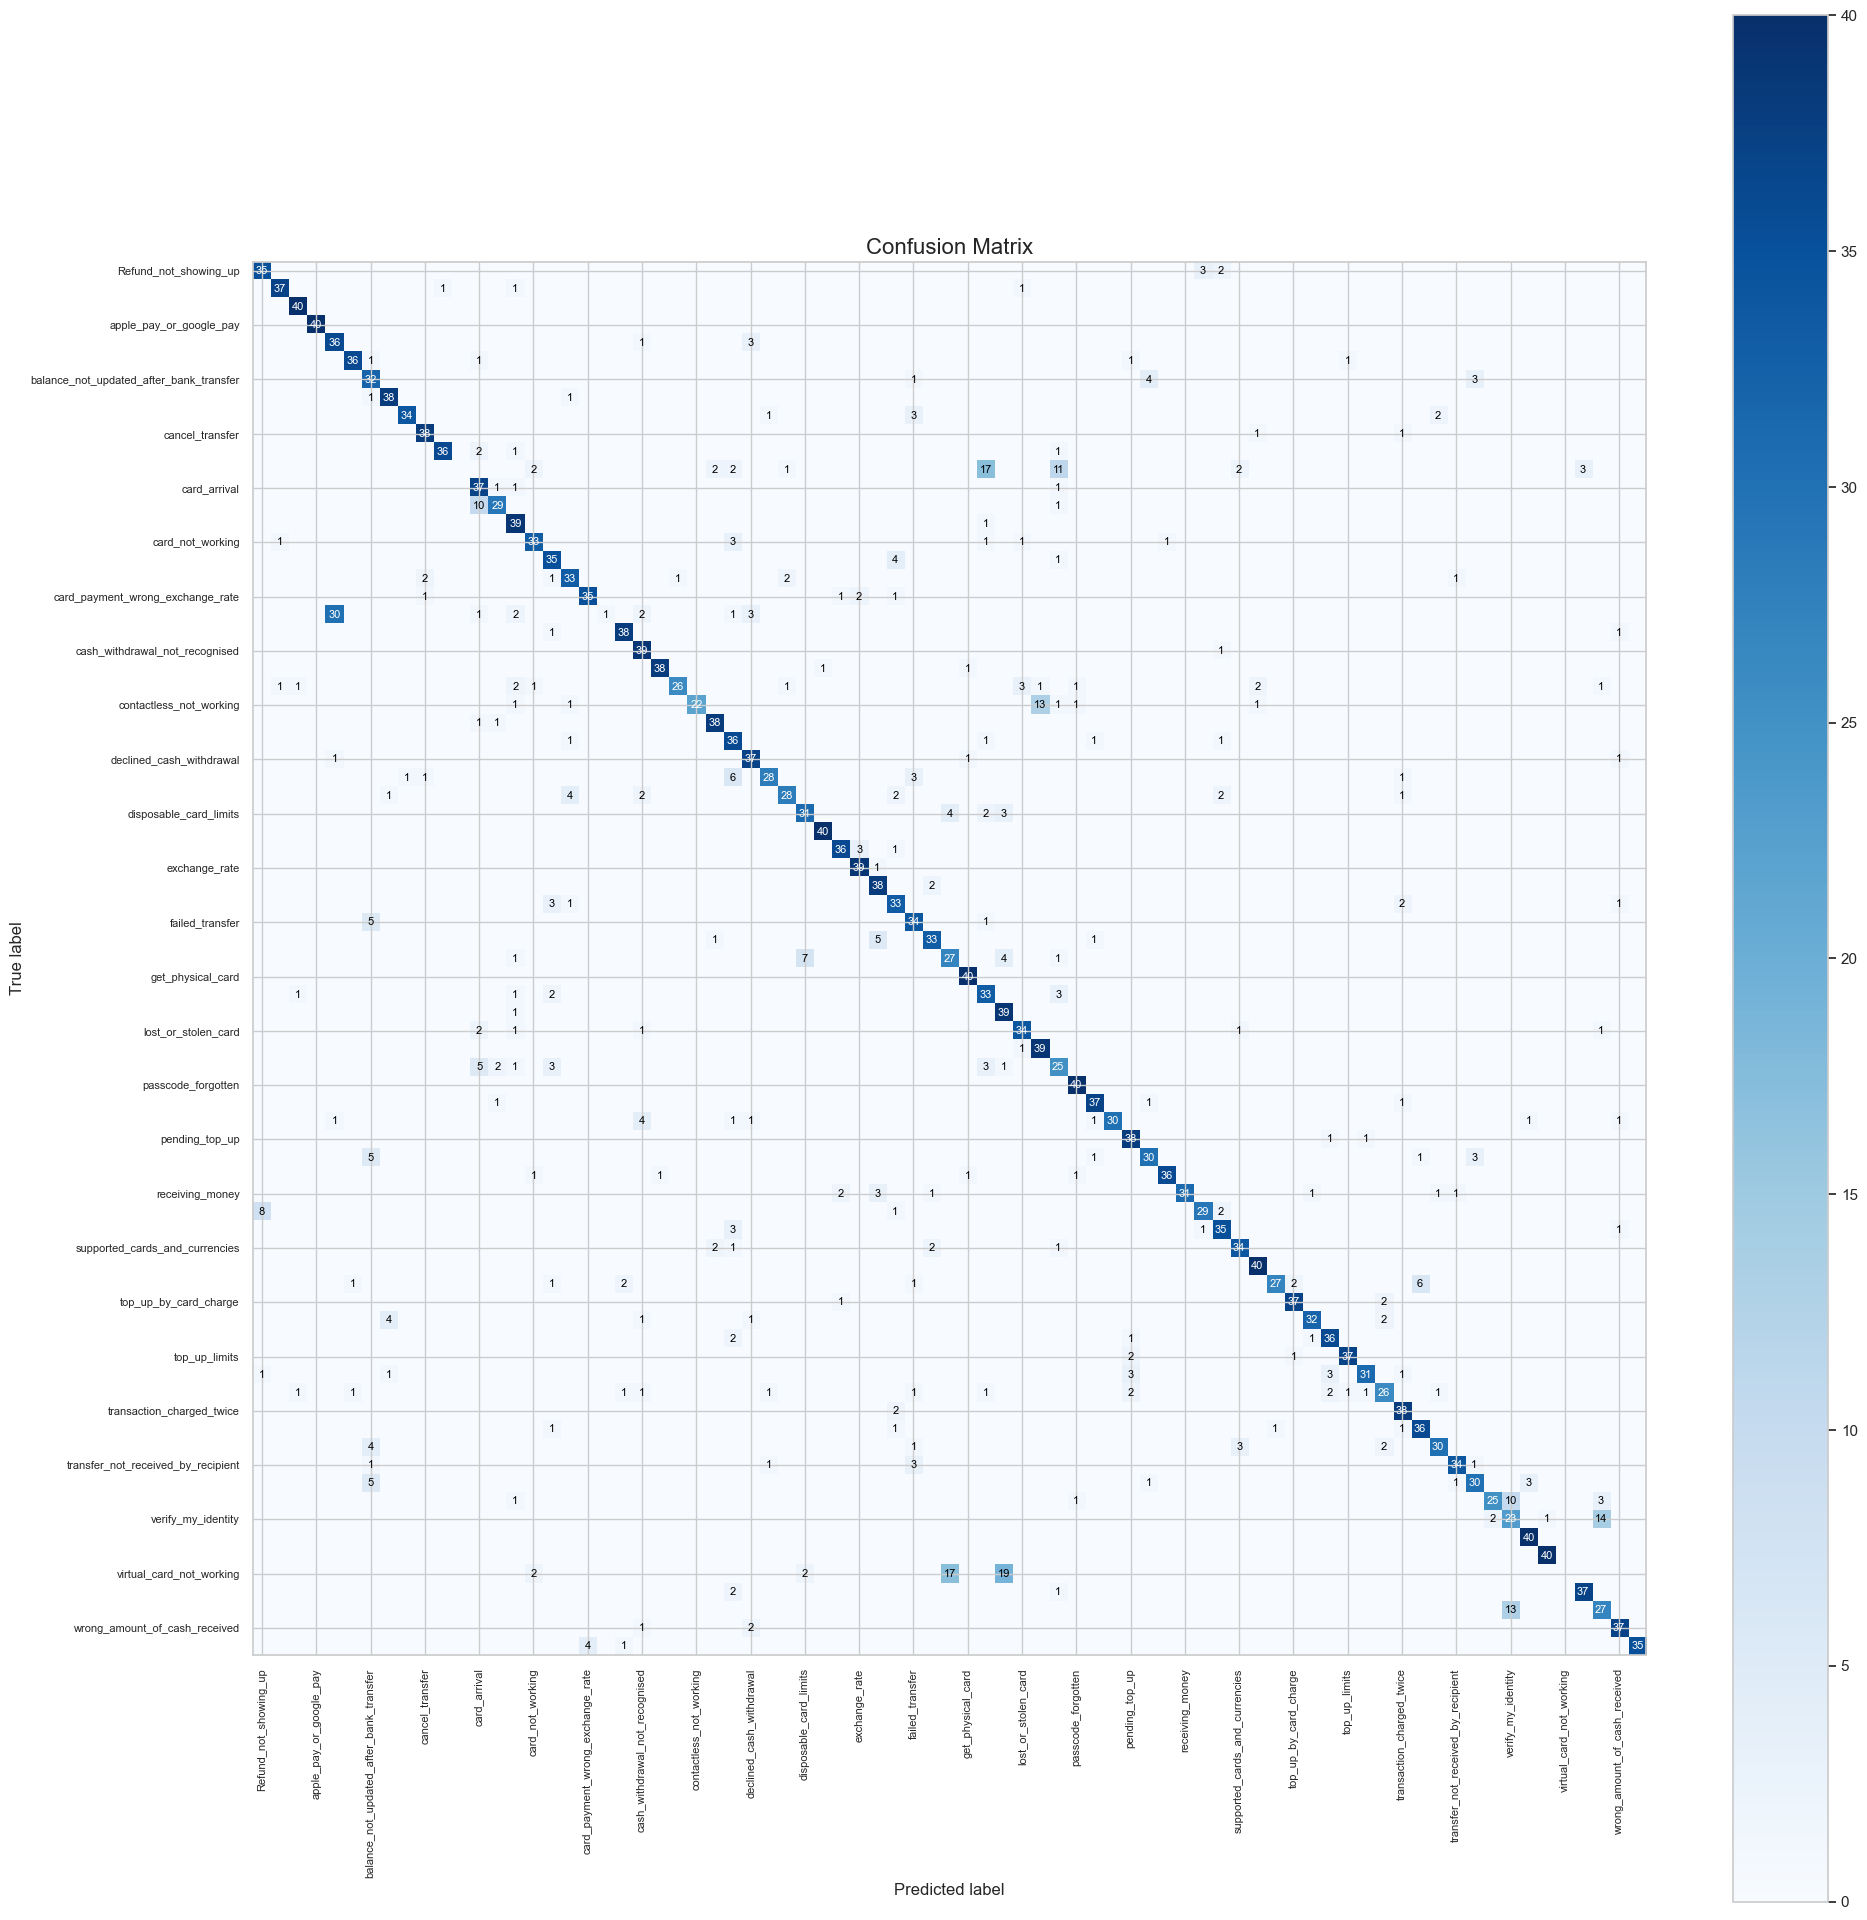

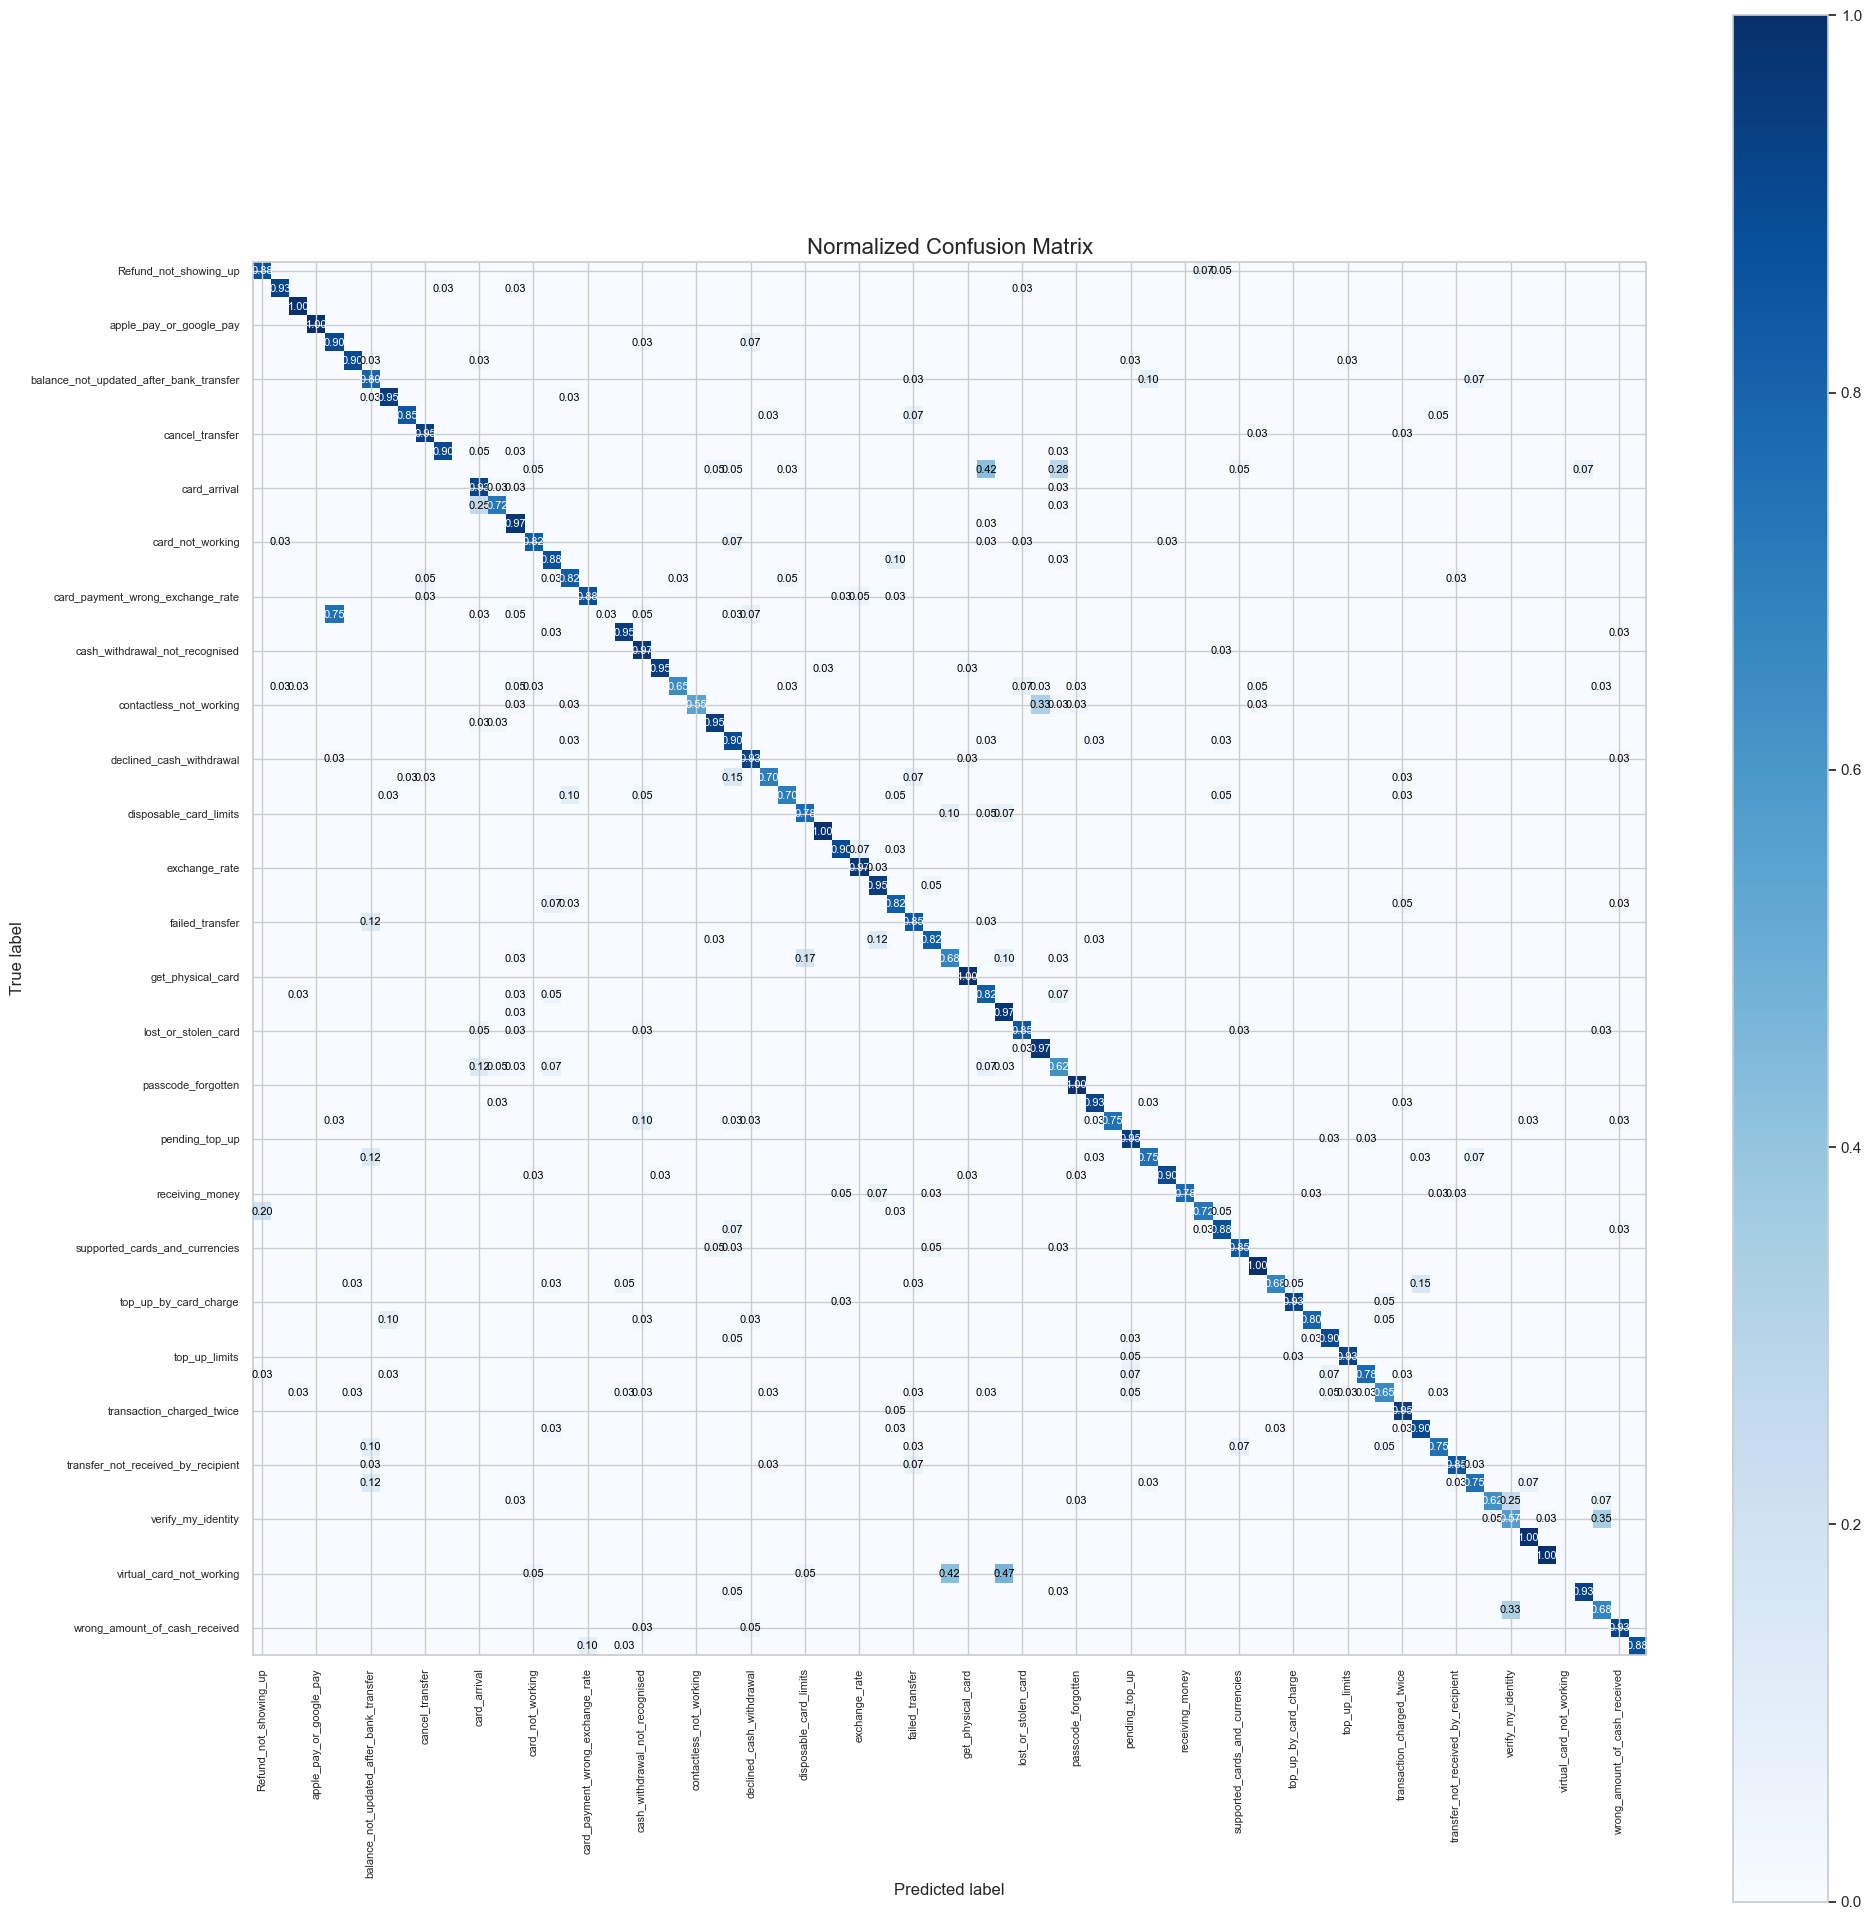


Top 10 most confused intent pairs:
True: card_swallowed, Predicted: atm_support, Count: 30
True: virtual_card_not_working, Predicted: getting_virtual_card, Count: 19
True: card_acceptance, Predicted: getting_spare_card, Count: 17
True: virtual_card_not_working, Predicted: get_disposable_virtual_card, Count: 17
True: verify_my_identity, Predicted: why_verify_identity, Count: 14
True: contactless_not_working, Predicted: lost_or_stolen_phone, Count: 13
True: why_verify_identity, Predicted: verify_my_identity, Count: 13
True: card_acceptance, Predicted: order_physical_card, Count: 11
True: card_delivery_estimate, Predicted: card_arrival, Count: 10
True: unable_to_verify_identity, Predicted: verify_my_identity, Count: 10


In [260]:
predictions_array = np.array(predictions)
true_labels_array = np.array(true_labels)
accuracy = np.mean(predictions_array == true_labels_array)
print(f"Final test accuracy: {accuracy:.4f}")
intent_names = label_encoder.classes_
print("\nClassification Report:")
report = classification_report(true_labels, predictions, target_names=intent_names, output_dict=True, zero_division=0)
print(classification_report(true_labels, predictions, target_names=intent_names, zero_division=0))
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('model_outputs/classification_report.csv')
cm = confusion_matrix(true_labels, predictions)
np.save('model_outputs/confusion_matrix.npy', cm)




print_confusion_matrix(cm, intent_names)
# Find most confused pairs
confusion_pairs = []
for i in range(num_labels):
    for j in range(num_labels):
        if i != j:
            confusion_pairs.append((i, j, cm[i, j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 most confused intent pairs:")
for i, j, count in confusion_pairs[:10]:
    true_intent = intent_names[i]
    pred_intent = intent_names[j]
    print(f"True: {true_intent}, Predicted: {pred_intent}, Count: {count}")

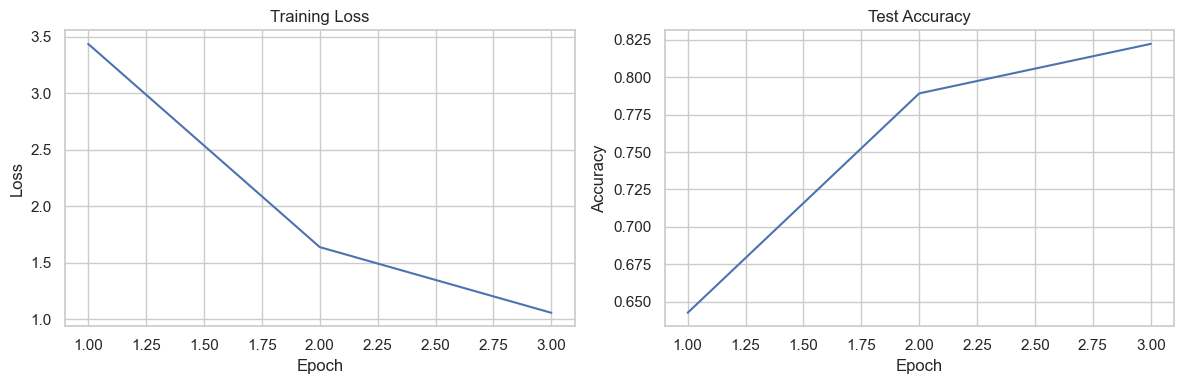

Training and evaluation complete!


In [261]:
# Plot training loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([stat['epoch'] for stat in training_stats], [stat['training_loss'] for stat in training_stats])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot([stat['epoch'] for stat in training_stats], [stat['test_accuracy'] for stat in training_stats])
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.savefig('model_outputs/training_metrics.png')
plt.show()

print("Training and evaluation complete!")